# PyTorch FashionMNIST Classification

## Phase 1 - Problem Definition

### Objective

The objective is to build a PyTorch image classifier that assigns each FashionMNIST image to one of 10 apparel categories. This is a supervised, single-label, multi-class classification problem.

### Task Formulation

- **Input:** a `28 x 28` grayscale image represented as a tensor with shape `[1, 28, 28]`.
- **Target:** one integer class label in the range `[0, 9]` (T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot).
- **Model output:** 10 raw logits, one for each FashionMNIST class.
- **Primary metric:** classification accuracy.
- **Optimization objective:** minimize cross-entropy loss on training data.

### Evaluation Protocol

The official FashionMNIST training pool is divided once with a fixed seed using a class-stratified 90/10 split:

- **Training subset:** 54,000 images used for preprocessing statistics, optimization and controlled experiments.
- **Validation subset:** 6,000 images used for epoch monitoring, hyperparameter comparison and model selection.
- **Official test set:** 10,000 images kept untouched until one final evaluation after all modeling decisions are fixed.

EDA may inspect the labeled official training pool before the split because it does not fit model parameters. Preprocessing statistics are computed only from the 54,000-image training subset. Validation and test images use the same deterministic transform and never receive random augmentation.

### Success Criteria

A valid solution must implement the complete PyTorch workflow: load and preprocess data, build a neural network, train with forward and backward passes, compare controlled experiments using validation metrics, evaluate the selected model once on the untouched test set, visualize learning behavior and predictions, and save then reload the selected model. Results are trustworthy only when the official test set remains isolated from preprocessing, optimization and model selection.

## Phase 2 - Environment Setup

This phase records the execution environment and imports the libraries required by the complete workflow.

In [1]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
PROJECT_CANDIDATES = (
    CURRENT_DIR,
    CURRENT_DIR / 'total_practice' / 'practice_1',
)
PROJECT_DIR = next(
    (path for path in PROJECT_CANDIDATES if (path / 'practice_1.ipynb').exists()),
    CURRENT_DIR,
)
DATA_DIR = PROJECT_DIR / 'data'
OUTPUT_DIR = PROJECT_DIR / 'outputs'
RUNS_DIR = PROJECT_DIR / 'runs'

if str(PROJECT_DIR.parent) not in sys.path:
    sys.path.append(str(PROJECT_DIR.parent))

In [2]:
%matplotlib inline
import sys
import torch
import torchvision
print(f"Python version: {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

Python version: 3.10.11
PyTorch version: 2.13.0
TorchVision version: 0.28.0
CUDA available: False
MPS available: True


In [3]:
import random
import time
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import (
    auc,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)
from collections import Counter
from torch.utils.data import DataLoader, Subset
from torch.utils.tensorboard import SummaryWriter
from practice_1.processing_own_phase.training_checkpoint import (
    TrainingCheckpointManager,
    atomic_torch_save,
    build_checkpoint_signature,
    capture_rng_state,
    clone_to_cpu,
    fingerprint_indices,
    restore_rng_state,
)
from practice_1.processing_own_phase.hyperparameter_search import (
    aggregate_confirmation_results,
    export_search_outputs,
    generate_architecture_trials,
    generate_confirmation_trials,
    generate_learning_rate_trials,
    rank_results,
    refinement_learning_rates,
)
from practice_1.processing_own_phase.training_monitor import TrainingMonitor
from typing import Dict, List, Optional, Sequence, cast
from mpl_toolkits.mplot3d import Axes3D

## Phase 3 - Data Loading

FashionMNIST is loaded from TorchVision using the two official partitions defined by the dataset.

- **Official training pool:** 60,000 labeled images used for EDA before a reproducible train/validation split.
- **Official test set:** 10,000 labeled images reserved for one final evaluation.

At this stage, `ToTensor()` is the only transform. It converts each PIL image to a `torch.float32` tensor with shape `[1, 28, 28]` and scales pixel values from `[0, 255]` to `[0, 1]`. The class-stratified split and final transforms are created in Phase 5 so that EDA observes original images while validation and test inputs remain deterministic.

In [4]:
SEED = 42
raw_transform = transforms.ToTensor()

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

train_dataset = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=raw_transform,
)
test_dataset = datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=raw_transform,
)
class_names = train_dataset.classes

print(f'Official training pool: {len(train_dataset):,}')
print(f'Official test set: {len(test_dataset):,}')

Official training pool: 60,000
Official test set: 10,000


## Phase 4 - Exploratory Data Analysis

EDA is restricted to the 60,000-image official training pool. The official test images and labels are not inspected. This phase audits schema, class balance, pixel intensity, image-level brightness and contrast, data quality, exact duplicates, representative class samples, class-average images and statistical extremes.

All statistics in this phase are descriptive. They do not replace the training-only normalization statistics computed from the 54,000 internal training samples in Phase 5.

### EDA Scope and Raw Data Contract

The analysis reads `train_dataset.data` and `train_dataset.targets` directly. FashionMNIST stores raw images as `uint8` tensors with shape `[N, 28, 28]`; chunked aggregation avoids creating a second full floating-point copy of the dataset.

In [5]:
from practice_1.processing_own_phase.data import analyze_training_pool
from practice_1.processing_own_phase.visualize import (
    plot_class_mean_images,
    plot_class_samples,
    plot_eda_class_distribution,
    plot_eda_outliers,
    plot_image_brightness_contrast,
    plot_per_class_intensity_boxplots,
    plot_pixel_intensity_distribution,
)

EDA_ANALYSIS = analyze_training_pool(
    train_dataset.data,
    train_dataset.targets,
    class_names=class_names,
    seed=SEED,
)
EDA_SUMMARY = EDA_ANALYSIS['report']

assert EDA_SUMMARY['scope'] == 'official_training_pool_only'
assert len(test_dataset) == 10_000

In [6]:
schema = EDA_SUMMARY['schema']

print(f"Samples: {schema['sample_count']:,}")
print(f"Raw shape: {tuple(train_dataset.data.shape)}")
print(f"Transformed sample shape: {tuple(train_dataset[0][0].shape)}")
print(f"Raw dtype: {schema['raw_dtype']}")
print(f"Raw range: [{schema['raw_min']}, {schema['raw_max']}]")
print(f"Label range: [{schema['label_min']}, {schema['label_max']}]")
print(f"Classes: {schema['class_count']}")

assert schema['sample_count'] == 60_000
assert (schema['height'], schema['width']) == (28, 28)
assert schema['channels'] == 1
assert schema['raw_dtype'] == 'torch.uint8'
assert (schema['raw_min'], schema['raw_max']) == (0, 255)
assert (schema['label_min'], schema['label_max']) == (0, 9)

Samples: 60,000
Raw shape: (60000, 28, 28)
Transformed sample shape: (1, 28, 28)
Raw dtype: torch.uint8
Raw range: [0, 255]
Label range: [0, 9]
Classes: 10


### Class Distribution

Class count and percentage are computed with `torch.bincount`. A bar chart is used instead of a pie chart because equal-height comparisons are easier to verify precisely.

In [7]:
class_distribution = EDA_SUMMARY['class_distribution']

for class_name, values in class_distribution.items():
    print(
        f"{class_name:12s}: "
        f"{values['count']:,} images "
        f"({values['percentage']:.1f}%)"
    )

assert all(
    values['count'] == 6_000
    for values in class_distribution.values()
)

plot_eda_class_distribution(
    EDA_ANALYSIS,
    class_names=class_names,
    save_path=str(OUTPUT_DIR / 'eda_class_distribution.png'),
)

T-shirt/top : 6,000 images (10.0%)
Trouser     : 6,000 images (10.0%)
Pullover    : 6,000 images (10.0%)
Dress       : 6,000 images (10.0%)
Coat        : 6,000 images (10.0%)
Sandal      : 6,000 images (10.0%)
Shirt       : 6,000 images (10.0%)
Sneaker     : 6,000 images (10.0%)
Bag         : 6,000 images (10.0%)
Ankle boot  : 6,000 images (10.0%)


![Official training-pool class distribution](./outputs/eda_class_distribution.png)

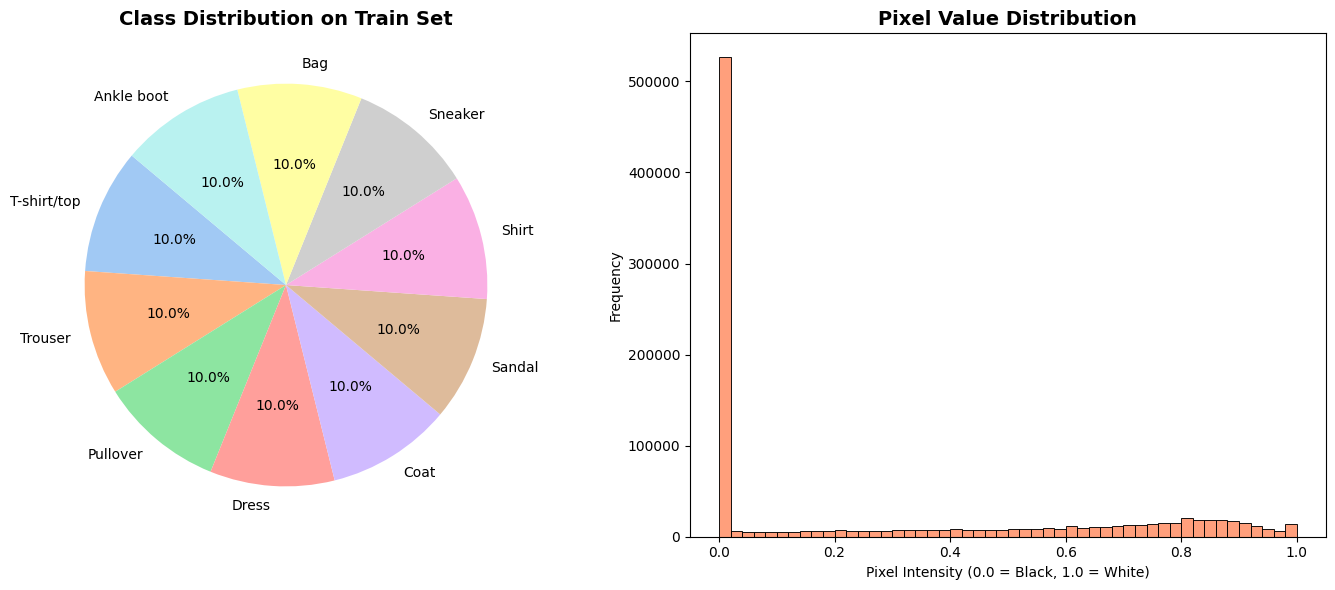

In [8]:
dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=60000, shuffle=False)
images, labels = next(iter(dataloader))

images_np = images.squeeze().numpy()
labels_np = labels.numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

class_counts = np.bincount(labels_np)
axes[0].pie(class_counts, labels=class_names, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
axes[0].set_title('Class Distribution on Train Set', fontsize=14, fontweight='bold')

sampled_pixels = np.random.choice(images_np.flatten(), size=1000000, replace=False)
sns.histplot(sampled_pixels, bins=50, kde=False, color='coral', ax=axes[1])
axes[1].set_title('Pixel Value Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Pixel Intensity (0.0 = Black, 1.0 = White)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Pixel Intensity Distribution

The exact 256-bin histogram covers all `60,000 x 28 x 28` raw pixels. The full view exposes the zero-valued background spike, while the non-zero view reveals the clothing intensity distribution.

In [9]:
pixel_statistics = EDA_SUMMARY['pixel_statistics']

print(f"Pixel count: {pixel_statistics['pixel_count']:,}")
print(f"Mean: {pixel_statistics['mean']:.6f}")
print(f"Standard deviation: {pixel_statistics['std']:.6f}")
print(f"Median: {pixel_statistics['median']:.6f}")
print(f"Q05/Q95: {pixel_statistics['q05']:.6f} / {pixel_statistics['q95']:.6f}")
print(f"Zero-valued pixels: {pixel_statistics['zero_fraction']:.2%}")
print(f"Maximum-valued pixels: {pixel_statistics['maximum_fraction']:.2%}")

assert pixel_statistics['pixel_count'] == 60_000 * 28 * 28
assert int(EDA_ANALYSIS['pixel_histogram'].sum()) == 60_000 * 28 * 28
assert 0.0 <= pixel_statistics['minimum']
assert pixel_statistics['maximum'] <= 1.0

plot_pixel_intensity_distribution(
    EDA_ANALYSIS,
    save_path=str(
        OUTPUT_DIR / 'pixel_intensity_distribution.png'
    ),
)

Pixel count: 47,040,000
Mean: 0.286041
Standard deviation: 0.353024
Median: 0.000000
Q05/Q95: 0.000000 / 0.905882
Zero-valued pixels: 50.21%
Maximum-valued pixels: 0.81%


![Pixel intensity distribution](./outputs/pixel_intensity_distribution.png)

### Image-Level Brightness and Contrast

Per-image mean intensity measures brightness, while per-image pixel standard deviation measures contrast. Their distributions reveal whether samples or classes occupy systematically different intensity ranges.

In [10]:
per_class_statistics = EDA_SUMMARY['per_class_statistics']

print(
    f"Overall image brightness mean: "
    f"{float(EDA_ANALYSIS['image_means'].mean()):.6f}"
)
print(
    f"Overall image contrast mean: "
    f"{float(EDA_ANALYSIS['image_stds'].mean()):.6f}"
)
print()

for class_name, values in per_class_statistics.items():
    print(
        f"{class_name:12s}: "
        f"brightness={values['mean_brightness']:.4f}, "
        f"contrast={values['mean_contrast']:.4f}"
    )

plot_image_brightness_contrast(
    EDA_ANALYSIS,
    save_path=str(
        OUTPUT_DIR / 'image_brightness_contrast.png'
    ),
)
plot_per_class_intensity_boxplots(
    EDA_ANALYSIS,
    class_names=class_names,
    save_path=str(
        OUTPUT_DIR / 'per_class_intensity_boxplot.png'
    ),
)

Overall image brightness mean: 0.286041
Overall image contrast mean: 0.320249

T-shirt/top : brightness=0.3256, contrast=0.3200
Trouser     : brightness=0.2229, contrast=0.3339
Pullover    : brightness=0.3767, contrast=0.3231
Dress       : brightness=0.2589, contrast=0.3359
Coat        : brightness=0.3853, contrast=0.3546
Sandal      : brightness=0.1367, contrast=0.2481
Shirt       : brightness=0.3318, contrast=0.2998
Sneaker     : brightness=0.1677, contrast=0.2850
Bag         : brightness=0.3536, contrast=0.3421
Ankle boot  : brightness=0.3012, contrast=0.3600


![Image brightness and contrast distributions](./outputs/image_brightness_contrast.png)

![Per-class brightness and contrast boxplots](./outputs/per_class_intensity_boxplot.png)

### Data Quality and Duplicate Audit

The quality audit checks transformed finiteness, all-black, all-white and constant images, invalid labels, missing classes, exact duplicate raw images and duplicate images assigned conflicting labels. Detected observations are reported for review and are not removed automatically.

In [11]:
quality = EDA_SUMMARY['quality']

for quality_name, value in quality.items():
    print(f"{quality_name}: {value}")

assert quality['non_finite_image_count'] == 0
assert quality['invalid_label_count'] == 0
assert quality['missing_class_count'] == 0
assert quality['conflicting_label_group_count'] == 0

non_finite_image_count: 0
black_image_count: 0
white_image_count: 0
constant_image_count: 0
invalid_label_count: 0
missing_class_count: 0
duplicate_group_count: 0
duplicate_sample_count: 0
additional_duplicate_count: 0
conflicting_label_group_count: 0


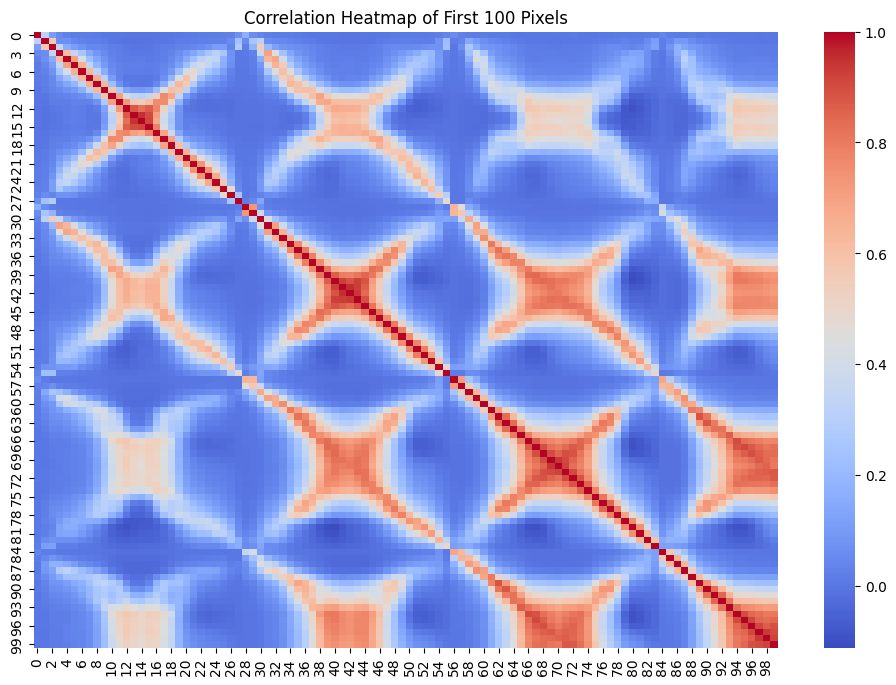

In [12]:
X_flatten = images_np.reshape(images_np.shape[0], -1).astype(np.float64, copy=False)
if not np.isfinite(X_flatten).all():
    raise ValueError('X_flatten contains NaN or infinite values.')

corr_first_100 = np.corrcoef(X_flatten[:, :100], rowvar=False)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_first_100, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap of First 100 Pixels")

plt.show()

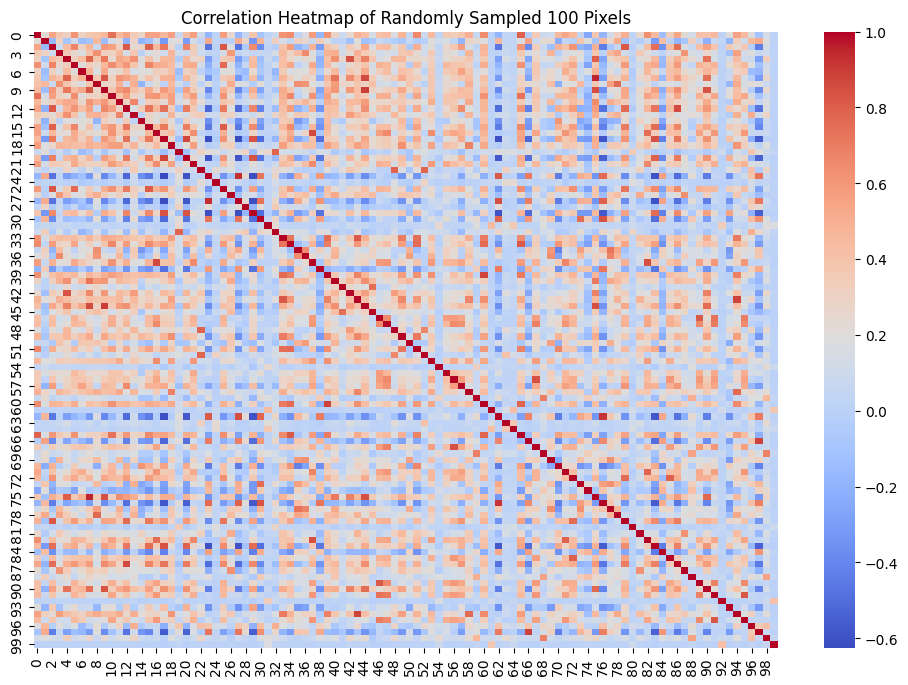

In [13]:
np.random.seed(42)
random_indices = np.random.choice(784, 100, replace=False)
corr_random_100 = np.corrcoef(X_flatten[:, random_indices], rowvar=False)

plt.figure(figsize=(12, 8))

sns.heatmap(corr_random_100, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap of Randomly Sampled 100 Pixels")
plt.show()

In [14]:
from sklearn.decomposition import PCA

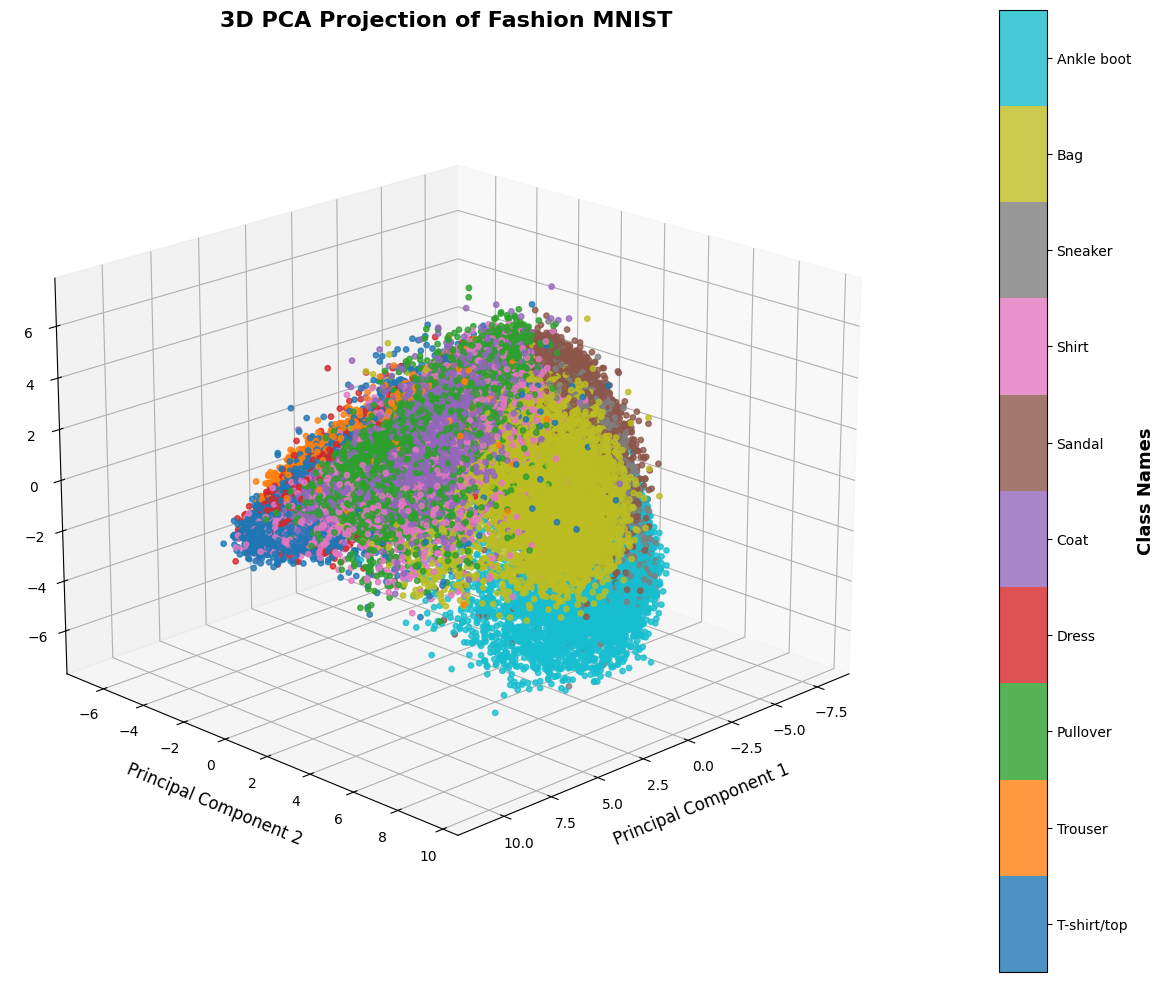

In [15]:
pca = PCA(n_components=3, svd_solver='full')
X_pca: np.ndarray = pca.fit_transform(X_flatten)
if not np.isfinite(X_pca).all():
    raise ValueError('PCA output contains NaN or infinite values.')

fig = plt.figure(figsize=(12, 10))
ax = cast(Axes3D, fig.add_subplot(111, projection='3d'))

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                     c=labels_np, cmap='tab10', alpha=0.8, s=15)

ax.set_xlabel("Principal Component 1", fontsize=12, labelpad=10)
ax.set_ylabel("Principal Component 2", fontsize=12, labelpad=10)
ax.set_zlabel("Principal Component 3", fontsize=12, labelpad=10)
ax.set_title("3D PCA Projection of Fashion MNIST", fontsize=16, fontweight='bold', pad=20)

cbar = plt.colorbar(scatter, ax=ax, pad=0.1, boundaries=np.arange(-0.5, 10.5, 1), ticks=range(10))
cbar.set_label("Class Names", fontsize=13, fontweight='bold')
cbar.set_ticks(range(10))
cbar.set_ticklabels(class_names)

ax.grid(True, linestyle='--', alpha=0.5)

ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()

In [16]:
explained_variance = pca.explained_variance_ratio_
print(f"Explained variance by PC1: {explained_variance[0]:.2%}")
print(f"Explained variance by PC2: {explained_variance[1]:.2%}")
print(f"Explained variance by PC3: {explained_variance[2]:.2%}")

Explained variance by PC1: 29.04%
Explained variance by PC2: 17.76%
Explained variance by PC3: 6.02%


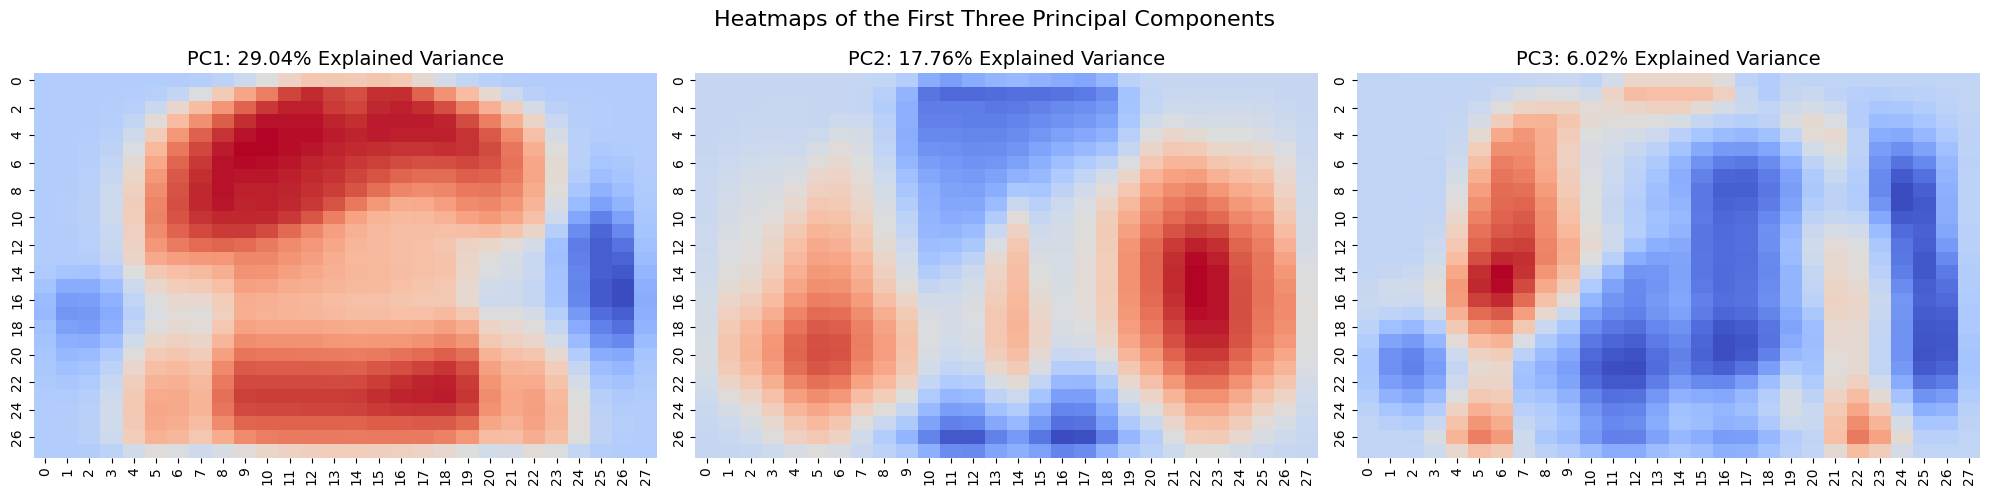

In [17]:
# Reuse the fitted PCA from the previous cell.
explained_variance_ratio = pca.explained_variance_ratio_

pc1 = pca.components_[0].reshape(28, 28)
pc2 = pca.components_[1].reshape(28, 28)
pc3 = pca.components_[2].reshape(28, 28)

fig, axarr = plt.subplots(1, 3, figsize=(20, 5))

sns.heatmap(pc1, cmap='coolwarm', ax=axarr[0], cbar=False)
axarr[0].set_title(f"PC1: {explained_variance_ratio[0]:.2%} Explained Variance", fontsize=14)

sns.heatmap(pc2, cmap='coolwarm', ax=axarr[1], cbar=False)
axarr[1].set_title(f"PC2: {explained_variance_ratio[1]:.2%} Explained Variance", fontsize=14)

sns.heatmap(pc3, cmap='coolwarm', ax=axarr[2], cbar=False)
axarr[2].set_title(f"PC3: {explained_variance_ratio[2]:.2%} Explained Variance", fontsize=14)

plt.suptitle("Heatmaps of the First Three Principal Components", fontsize=16)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flatten)

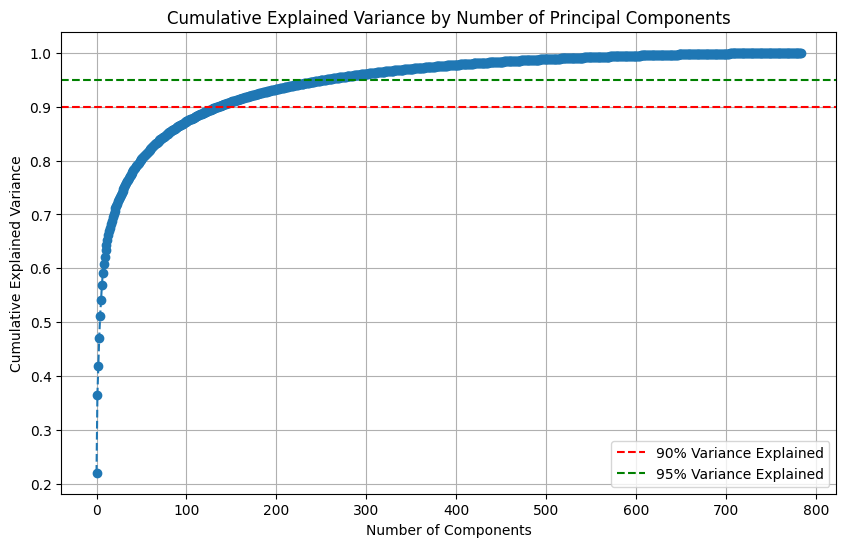

In [20]:
pca_full = PCA(svd_solver='full')
pca_full.fit(X_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Variance Explained')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Variance Explained')
plt.title("Cumulative Explained Variance by Number of Principal Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.legend()

plt.show()

In [21]:
# Determine the number of components needed for 90% and 95% variance explained
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Ideal number of components for 90% variance explained: {n_components_90}")
print(f"Ideal number of components for 95% variance explained: {n_components_95}")

Ideal number of components for 90% variance explained: 137
Ideal number of components for 95% variance explained: 256


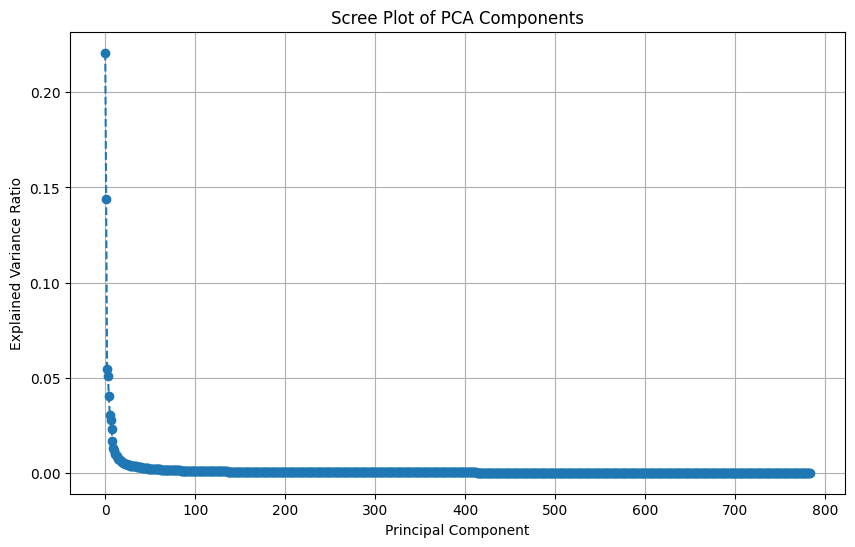

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(explained_variance_ratio, marker='o', linestyle='--')
plt.title("Scree Plot of PCA Components")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid()

plt.show()

In [23]:
from sklearn.manifold import TSNE

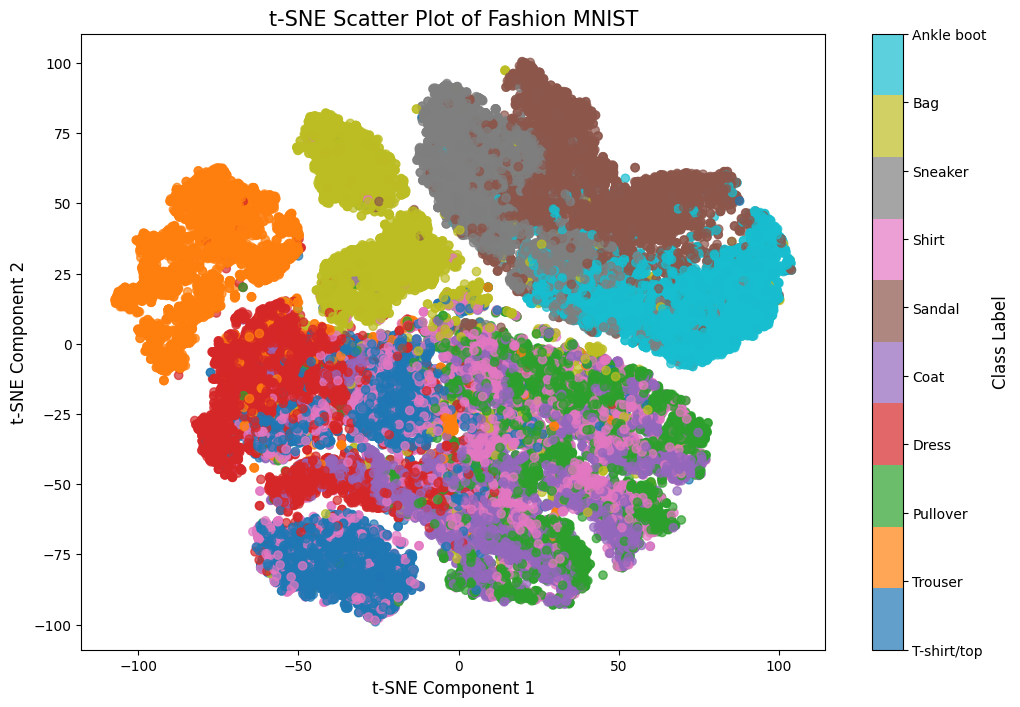

In [24]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=1000,
    init='random',
    learning_rate='auto',
)
X_train_tsne: np.ndarray = tsne.fit_transform(X_scaled)
if not np.isfinite(X_train_tsne).all():
    raise ValueError('t-SNE output contains NaN or infinite values.')

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_train_tsne[:, 0],
    X_train_tsne[:, 1],
    c=labels_np,
    cmap='tab10',
    alpha=0.7
)

plt.title('t-SNE Scatter Plot of Fashion MNIST', fontsize=15)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)

cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label('Class Label', fontsize=12)
cbar.set_ticks(range(10))
cbar.set_ticklabels(class_names)

plt.show()

### Class-Stratified Samples and Mean Images

Two deterministic samples are selected from every class with seed 42. Class-average images summarize the common silhouette and expose visual overlap between related garment categories.

In [25]:
assert len(EDA_ANALYSIS['sample_indices']) == 20
assert len(set(EDA_ANALYSIS['sample_indices'])) == 20

plot_class_samples(
    train_dataset.data,
    EDA_ANALYSIS,
    class_names=class_names,
    save_path=str(OUTPUT_DIR / 'class_samples.png'),
)
plot_class_mean_images(
    EDA_ANALYSIS,
    class_names=class_names,
    save_path=str(OUTPUT_DIR / 'class_mean_images.png'),
)

![Class-stratified FashionMNIST samples](./outputs/class_samples.png)

![Class-average FashionMNIST images](./outputs/class_mean_images.png)

### Statistical Extremes

The darkest, brightest, lowest-contrast and highest-contrast samples are displayed as review candidates. Extreme statistics alone are not evidence of corruption, so these images remain in the dataset.

In [26]:
plot_eda_outliers(
    train_dataset.data,
    train_dataset.targets,
    EDA_ANALYSIS,
    class_names=class_names,
    save_path=str(OUTPUT_DIR / 'eda_outliers.png'),
)

![Brightness and contrast extremes](./outputs/eda_outliers.png)

### EDA Conclusions

- The official training pool contains 60,000 valid `28 x 28` grayscale images and 10 balanced classes with 6,000 samples each. Accuracy is therefore suitable as the primary selection metric, and baseline class weighting is unnecessary.
- Approximately half of all raw pixels are zero-valued background pixels. The non-zero distribution remains broad, supporting global normalization before optimization.
- Brightness and contrast vary across classes, especially between footwear and upper-body garments. Class-specific normalization is not used because inference does not know the true class.
- No invalid labels, missing classes, constant images, exact duplicate images or conflicting-label duplicate groups were detected in the current dataset copy.
- Mean images show clear silhouette overlap among T-shirt/top, Pullover, Coat and Shirt, anticipating the confusion pattern examined after model evaluation.
- Statistical extremes remain recognizable garments and are retained. EDA does not perform automatic deletion.
- The global EDA mean and standard deviation are descriptive only. Phase 5 independently computes normalization statistics from the 54,000 internal training samples to preserve the validation boundary.

## Phase 5 - Data Preprocessing

The 60,000-image official training pool is divided with a fixed, class-stratified 90/10 split. This creates 54,000 training samples and 6,000 validation samples while preserving exactly 10% of every class for validation. The official 10,000-image test set remains separate.

Normalization statistics are computed only from the training indices. The baseline transform is deterministic so architecture and optimizer experiments remain controlled. A separate augmented training dataset is prepared for an explicit augmentation experiment. Validation and test transforms contain no random operations.

### Split and Transform Strategy

The split is created before transformed datasets and DataLoaders. Separate FashionMNIST instances allow training, validation and test samples to use independent transform policies without sharing stochastic augmentation.

- Baseline training: tensor conversion and training-subset normalization.
- Augmented training experiment: horizontal flip, small rotation, tensor conversion and the same normalization.
- Validation and test: deterministic tensor conversion and the same normalization.

This structure prevents validation augmentation, train/validation overlap and official-test leakage.

In [27]:
VALIDATION_RATIO = 0.10
split_generator = torch.Generator().manual_seed(SEED)
targets = train_dataset.targets
train_index_parts = []
validation_index_parts = []

for class_index in range(len(class_names)):
    class_indices = torch.where(targets == class_index)[0]
    class_order = torch.randperm(len(class_indices), generator=split_generator)
    shuffled_indices = class_indices[class_order]
    validation_count = int(len(class_indices) * VALIDATION_RATIO)
    validation_index_parts.append(shuffled_indices[:validation_count])
    train_index_parts.append(shuffled_indices[validation_count:])

train_indices = torch.cat(train_index_parts)
validation_indices = torch.cat(validation_index_parts)
train_indices = train_indices[
    torch.randperm(len(train_indices), generator=split_generator)
]
validation_indices = validation_indices[
    torch.randperm(len(validation_indices), generator=split_generator)
]

training_pixels = train_dataset.data[train_indices].to(torch.float32).div(255.0)
TRAIN_MEAN = training_pixels.mean().item()
TRAIN_STD = training_pixels.std().item()
del training_pixels

baseline_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((TRAIN_MEAN,), (TRAIN_STD,)),
])

augmented_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize((TRAIN_MEAN,), (TRAIN_STD,)),
])

evaluation_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((TRAIN_MEAN,), (TRAIN_STD,)),
])

print(f'Training mean: {TRAIN_MEAN:.6f}')
print(f'Training std: {TRAIN_STD:.6f}')

Training mean: 0.286139
Training std: 0.353084


### Dataset Construction

Three independent views of the official training pool are created. Training and validation subsets use disjoint indices, while separate parent datasets enforce their transform contracts. The augmented view reuses only training indices and is reserved for a controlled experiment.

In [28]:
baseline_training_pool = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=baseline_transform,
)
augmented_training_pool = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=augmented_transform,
)
validation_pool = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=evaluation_transform,
)
test_dataset = datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    download=False,
    transform=evaluation_transform,
)

train_subset = Subset(baseline_training_pool, train_indices.tolist())
augmented_train_subset = Subset(
    augmented_training_pool,
    train_indices.tolist(),
)
validation_subset = Subset(
    validation_pool,
    validation_indices.tolist(),
)

### DataLoaders

The baseline loader shuffles only the training subset. Validation and test loaders preserve deterministic ordering. A loader factory is introduced later in the training phase so every controlled experiment receives a fresh shuffle generator.

In [29]:
BATCH_SIZE = 64
loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=loader_generator,
    num_workers=0,
)
validation_loader = DataLoader(
    validation_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

### Pipeline Sanity Checks

Before model construction, the split, class balance, transforms and loader contracts are verified. Expected batches contain `float32` images with shape `[B, 1, 28, 28]` and `int64` labels with shape `[B]`. Validation samples must be deterministic and the official test set must remain independent.

In [30]:
assert len(train_subset) == 54_000
assert len(augmented_train_subset) == 54_000
assert len(validation_subset) == 6_000
assert len(test_dataset) == 10_000
assert len(set(train_indices.tolist()).intersection(validation_indices.tolist())) == 0
assert len(torch.unique(torch.cat((train_indices, validation_indices)))) == 60_000

train_class_counts = torch.bincount(targets[train_indices], minlength=10)
validation_class_counts = torch.bincount(
    targets[validation_indices],
    minlength=10,
)

assert torch.equal(train_class_counts, torch.full((10,), 5_400))
assert torch.equal(validation_class_counts, torch.full((10,), 600))

validation_image_a, validation_label_a = validation_subset[0]
validation_image_b, validation_label_b = validation_subset[0]
assert torch.equal(validation_image_a, validation_image_b)
assert validation_label_a == validation_label_b

print(f'Train batches: {len(train_loader)}')
print(f'Validation batches: {len(validation_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 844
Validation batches: 94
Test batches: 157


In [31]:
train_images, train_labels = next(iter(train_loader))
validation_images, validation_labels = next(iter(validation_loader))
test_images, test_labels = next(iter(test_loader))

for split_name, images, labels in (
    ('Train', train_images, train_labels),
    ('Validation', validation_images, validation_labels),
    ('Test', test_images, test_labels),
):
    assert images.ndim == 4
    assert images.shape[1:] == (1, 28, 28)
    assert images.dtype == torch.float32
    assert labels.ndim == 1
    assert labels.dtype == torch.int64
    assert torch.isfinite(images).all()
    print(
        f'{split_name}: images={tuple(images.shape)}, '
        f'labels={tuple(labels.shape)}, '
        f'range=[{images.min().item():.3f}, {images.max().item():.3f}]'
    )

Train: images=(64, 1, 28, 28), labels=(64,), range=[-0.810, 2.022]
Validation: images=(64, 1, 28, 28), labels=(64,), range=[-0.810, 2.022]
Test: images=(64, 1, 28, 28), labels=(64,), range=[-0.810, 2.022]


## Phase 6 - Model Building

The baseline is a configurable multi-layer perceptron. It converts each normalized `1 x 28 x 28` image into a flat 784-feature vector and returns one raw logit for each of the 10 classes.

The model intentionally excludes Softmax because `CrossEntropyLoss` consumes raw logits. Constructor validation protects architecture configuration, while runtime tensor compatibility is verified once by a fail-fast sanity check before training.

In [32]:
class FashionMNISTModel(nn.Module):
    def __init__(
        self,
        hidden_dims: Optional[Sequence[int]] = None,
        dropout: float = 0.0,
        num_classes: int = 10,
        input_dim: int = 28 * 28,
    ):
        super().__init__()
        resolved_hidden_dims = (
            (128,) if hidden_dims is None else tuple(hidden_dims)
        )

        if input_dim <= 0:
            raise ValueError('input_dim must be positive')
        if num_classes <= 1:
            raise ValueError('num_classes must be greater than one')
        if any(hidden_dim <= 0 for hidden_dim in resolved_hidden_dims):
            raise ValueError('hidden dimensions must be positive')
        if not 0.0 <= dropout < 1.0:
            raise ValueError('dropout must be in the interval [0, 1)')

        layers: List[nn.Module] = [nn.Flatten()]
        in_features = input_dim

        for hidden_dim in resolved_hidden_dims:
            layers.extend((nn.Linear(in_features, hidden_dim), nn.ReLU()))
            if dropout > 0.0:
                layers.append(nn.Dropout(dropout))
            in_features = hidden_dim

        layers.append(nn.Linear(in_features, num_classes))

        self.network = nn.Sequential(*layers)
        self.hidden_dims = resolved_hidden_dims
        self.dropout = dropout
        self.num_classes = num_classes
        self.input_dim = input_dim

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.network(inputs)

In [33]:
BASELINE_CONFIG = {
    'experiment_id': 'E0_baseline',
    'hidden_dims': (128,),
    'dropout': 0.0,
    'num_classes': 10,
    'input_dim': 28 * 28,
    'optimizer': 'Adam',
    'learning_rate': 0.001,
    'weight_decay': 0.0,
    'batch_size': BATCH_SIZE,
    'epochs': 10,
    'use_augmentation': False,
}


def build_model(config: Dict) -> FashionMNISTModel:
    return FashionMNISTModel(
        hidden_dims=config['hidden_dims'],
        dropout=config['dropout'],
        num_classes=config['num_classes'],
        input_dim=config['input_dim'],
    )


def count_trainable_parameters(model: nn.Module) -> int:
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


model = build_model(BASELINE_CONFIG)
parameter_count = count_trainable_parameters(model)

print(model)
print(f'Trainable parameters: {parameter_count:,}')

FashionMNISTModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Trainable parameters: 101,770


In [34]:
def sanity_check_model(
    model: FashionMNISTModel,
    images: torch.Tensor,
    labels: torch.Tensor,
) -> Dict:
    sanity_model = build_model({
        'hidden_dims': model.hidden_dims,
        'dropout': model.dropout,
        'num_classes': model.num_classes,
        'input_dim': model.input_dim,
    })
    sanity_model.train()
    sanity_images = images[:8]
    sanity_labels = labels[:8]

    parameter = next(sanity_model.parameters())
    assert sanity_images.shape == (8, 1, 28, 28)
    assert sanity_images.dtype == parameter.dtype
    assert sanity_images.device == parameter.device
    assert sanity_labels.shape == (8,)
    assert sanity_labels.dtype == torch.int64

    logits = sanity_model(sanity_images)
    assert logits.shape == (8, sanity_model.num_classes)
    assert torch.isfinite(logits).all()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(sanity_model.parameters(), lr=0.01)
    loss = criterion(logits, sanity_labels)
    assert torch.isfinite(loss)

    parameter_snapshot = {
        name: value.detach().clone()
        for name, value in sanity_model.named_parameters()
    }

    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    gradients = [
        parameter.grad
        for parameter in sanity_model.parameters()
        if parameter.requires_grad
    ]
    assert all(gradient is not None for gradient in gradients)
    assert all(torch.isfinite(gradient).all() for gradient in gradients)
    assert any(gradient.abs().sum().item() > 0 for gradient in gradients)

    optimizer.step()

    parameters_changed = any(
        not torch.equal(
            parameter_snapshot[name],
            parameter.detach(),
        )
        for name, parameter in sanity_model.named_parameters()
    )
    assert parameters_changed

    return {
        'output_shape': tuple(logits.shape),
        'loss': loss.item(),
        'gradients_finite': True,
        'parameters_changed': parameters_changed,
    }


MODEL_SANITY = sanity_check_model(model, train_images, train_labels)

assert parameter_count == 101_770
print(f"Output shape: {MODEL_SANITY['output_shape']}")
print(f"Finite loss: {MODEL_SANITY['loss']:.6f}")
print(f"Gradients finite: {MODEL_SANITY['gradients_finite']}")
print(f"Parameters changed: {MODEL_SANITY['parameters_changed']}")

Output shape: (8, 10)
Finite loss: 2.219638
Gradients finite: True
Parameters changed: True


## Phase 7 - Model Training

Every training run starts from fresh model and optimizer state. The training subset is optimized with `CrossEntropyLoss`, while the deterministic validation subset is evaluated after every epoch. Validation accuracy selects the checkpoint for each experiment; the official test loader is not accepted by any training function.

Epoch loss is a sample-weighted mean, accuracy is stored as a fraction in `[0, 1]`, and TensorBoard receives the same metrics recorded in the returned history.

In [35]:
def set_reproducibility(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def select_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


device = select_device()
print(f'Selected device: {device}')

Selected device: mps


In [36]:
def make_train_loader(
    dataset,
    batch_size: int,
    seed: int,
) -> DataLoader:
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        num_workers=0,
    )


def build_optimizer(
    model: nn.Module,
    config: Dict,
) -> torch.optim.Optimizer:
    optimizer_name = config['optimizer'].lower()
    learning_rate = config['learning_rate']
    weight_decay = config.get('weight_decay', 0.0)

    if optimizer_name == 'adam':
        return optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay,
        )
    if optimizer_name == 'sgd':
        return optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=config.get('momentum', 0.9),
            weight_decay=weight_decay,
        )
    raise ValueError(f'Unsupported optimizer: {config["optimizer"]}')

In [37]:
def evaluate_loader(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> Dict[str, float]:
    model.eval()
    loss_sum = 0.0
    correct = 0
    sample_count = 0

    with torch.inference_mode():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            batch_size = labels.size(0)

            if not torch.isfinite(loss):
                raise FloatingPointError('Non-finite evaluation loss')

            loss_sum += loss.item() * batch_size
            correct += logits.argmax(dim=1).eq(labels).sum().item()
            sample_count += batch_size

    if sample_count == 0:
        raise ValueError('Evaluation loader is empty')

    return {
        'loss': loss_sum / sample_count,
        'accuracy': correct / sample_count,
        'sample_count': sample_count,
    }

In [38]:
def train_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> Dict[str, float]:
    model.train()
    loss_sum = 0.0
    correct = 0
    sample_count = 0
    started_at = time.perf_counter()

    for batch_index, (images, labels) in enumerate(data_loader):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)

        if not torch.isfinite(loss):
            raise FloatingPointError(
                f'Non-finite training loss at batch {batch_index}'
            )

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        loss_sum += loss.item() * batch_size
        correct += logits.argmax(dim=1).eq(labels).sum().item()
        sample_count += batch_size

    if sample_count == 0:
        raise ValueError('Training loader is empty')

    return {
        'loss': loss_sum / sample_count,
        'accuracy': correct / sample_count,
        'sample_count': sample_count,
        'elapsed_seconds': time.perf_counter() - started_at,
    }

In [39]:
def run_training(
    config: Dict,
    training_dataset,
    validation_loader: DataLoader,
    device: torch.device,
    log_directory: Optional[Path] = None,
    verbose: bool = True,
    monitor: Optional[TrainingMonitor] = None,
    checkpoint_manager: Optional[TrainingCheckpointManager] = None,
    resume_from_checkpoint: bool = True,
) -> Dict:
    set_reproducibility(config.get('seed', SEED))
    model = build_model(config).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model, config)
    train_loader = make_train_loader(
        training_dataset,
        batch_size=config['batch_size'],
        seed=config.get('seed', SEED),
    )
    history = []
    best_state = None
    best_epoch = 0
    best_validation_accuracy = -1.0
    best_validation_loss = float('inf')
    active_log_directory = log_directory
    resumed_from_epoch = 0
    elapsed_before_resume = 0.0
    total_elapsed_seconds = 0.0
    recovery_state = (
        checkpoint_manager.load(map_location='cpu')
        if checkpoint_manager is not None and resume_from_checkpoint
        else None
    )

    if recovery_state is not None:
        if recovery_state['total_epochs'] != config['epochs']:
            raise RuntimeError(
                'Recovery checkpoint epoch budget does not match config'
            )
        model.load_state_dict(recovery_state['model_state_dict'])
        optimizer.load_state_dict(recovery_state['optimizer_state_dict'])
        history = list(recovery_state['history'])
        best_state = recovery_state['best_state_dict']
        best_epoch = recovery_state['best_epoch']
        best_validation_accuracy = (
            recovery_state['best_validation_accuracy']
        )
        best_validation_loss = recovery_state['best_validation_loss']
        resumed_from_epoch = recovery_state['completed_epoch']
        elapsed_before_resume = recovery_state['elapsed_seconds']
        total_elapsed_seconds = elapsed_before_resume
        if recovery_state['log_directory']:
            active_log_directory = Path(
                recovery_state['log_directory']
            )
        restore_rng_state(
            recovery_state['rng_state'],
            train_loader.generator,
        )
        if verbose:
            print(
                f"Resuming {config['experiment_id']} after epoch "
                f"{resumed_from_epoch}/{config['epochs']}"
            )

    start_epoch = resumed_from_epoch + 1
    writer = (
        SummaryWriter(
            log_dir=str(active_log_directory),
            purge_step=(start_epoch if resumed_from_epoch else None),
        )
        if (
            active_log_directory is not None
            and start_epoch <= config['epochs']
        )
        else None
    )
    if monitor is not None and history:
        monitor.restore(history, best_epoch=best_epoch)
    started_at = time.perf_counter()

    try:
        for epoch in range(start_epoch, config['epochs'] + 1):
            train_metrics = train_one_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
                device,
            )
            validation_metrics = evaluate_loader(
                model,
                validation_loader,
                criterion,
                device,
            )
            learning_rate = optimizer.param_groups[0]['lr']
            epoch_record = {
                'epoch': epoch,
                'train_loss': train_metrics['loss'],
                'train_accuracy': train_metrics['accuracy'],
                'validation_loss': validation_metrics['loss'],
                'validation_accuracy': validation_metrics['accuracy'],
                'learning_rate': learning_rate,
                'elapsed_seconds': train_metrics['elapsed_seconds'],
            }
            history.append(epoch_record)

            validation_is_better = (
                validation_metrics['accuracy'] > best_validation_accuracy
                or (
                    validation_metrics['accuracy']
                    == best_validation_accuracy
                    and validation_metrics['loss'] < best_validation_loss
                )
            )
            if validation_is_better:
                best_epoch = epoch
                best_validation_accuracy = validation_metrics['accuracy']
                best_validation_loss = validation_metrics['loss']
                best_state = {
                    name: value.detach().cpu().clone()
                    for name, value in model.state_dict().items()
                }

            if writer is not None:
                writer.add_scalar(
                    'Loss/Train',
                    train_metrics['loss'],
                    epoch,
                )
                writer.add_scalar(
                    'Loss/Validation',
                    validation_metrics['loss'],
                    epoch,
                )
                writer.add_scalar(
                    'Accuracy/Train',
                    train_metrics['accuracy'],
                    epoch,
                )
                writer.add_scalar(
                    'Accuracy/Validation',
                    validation_metrics['accuracy'],
                    epoch,
                )
                writer.add_scalar(
                    'LearningRate',
                    learning_rate,
                    epoch,
                )
                writer.flush()

            total_elapsed_seconds = (
                elapsed_before_resume
                + time.perf_counter() - started_at
            )
            if checkpoint_manager is not None:
                checkpoint_manager.save({
                    'status': (
                        'completed'
                        if epoch == config['epochs']
                        else 'in_progress'
                    ),
                    'completed_epoch': epoch,
                    'total_epochs': config['epochs'],
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'history': history,
                    'best_state_dict': best_state,
                    'best_epoch': best_epoch,
                    'best_validation_accuracy': (
                        best_validation_accuracy
                    ),
                    'best_validation_loss': best_validation_loss,
                    'rng_state': capture_rng_state(
                        train_loader.generator
                    ),
                    'elapsed_seconds': total_elapsed_seconds,
                    'log_directory': (
                        str(active_log_directory)
                        if active_log_directory is not None
                        else ''
                    ),
                })

            if monitor is not None:
                monitor.update(epoch_record, best_epoch=best_epoch)

            if verbose:
                print(
                    f"Epoch {epoch:02d}/{config['epochs']} | "
                    f"Train Loss {train_metrics['loss']:.4f} | "
                    f"Train Accuracy {train_metrics['accuracy']:.2%} | "
                    f"Validation Loss {validation_metrics['loss']:.4f} | "
                    f"Validation Accuracy "
                    f"{validation_metrics['accuracy']:.2%}"
                )
    finally:
        if writer is not None:
            writer.close()

    if best_state is None:
        raise RuntimeError('Training did not produce a valid checkpoint')

    model.load_state_dict(best_state)
    model.to(device)
    model.eval()

    return {
        'experiment_id': config['experiment_id'],
        'config': dict(config),
        'model': model,
        'history': history,
        'best_epoch': best_epoch,
        'best_validation_accuracy': best_validation_accuracy,
        'best_validation_loss': best_validation_loss,
        'parameter_count': count_trainable_parameters(model),
        'training_sample_count': len(training_dataset),
        'total_seconds': (
            total_elapsed_seconds
            if history
            else time.perf_counter() - started_at
        ),
        'resumed_from_epoch': resumed_from_epoch,
        'recovery_checkpoint_path': (
            str(checkpoint_manager.path)
            if checkpoint_manager is not None
            else None
        ),
    }

### Controlled Experiments

Five experiments explore modeling choices in two stages. E1 first isolates the effect
of a deeper architecture against the original baseline (E0). Using E1's architecture
as the new anchor, E2, E3 and E4 each then isolate exactly one additional factor —
dropout, optimizer choice, and data augmentation respectively. Every run receives the
same train/validation indices, epoch budget, seed and fresh shuffle generator.
Validation accuracy is the primary selection metric, with validation loss used only
as a tie-breaker. The official test set remains untouched.

In [40]:
COMMON_EXPERIMENT_CONFIG = {
    'num_classes': 10,
    'input_dim': 28 * 28,
    'weight_decay': 0.0,
    'batch_size': BATCH_SIZE,
    'epochs': 10,
    'seed': SEED,
    'use_augmentation': False,
}

EXPERIMENT_CONFIGS = [
    {
        **COMMON_EXPERIMENT_CONFIG,
        'experiment_id': 'E0_baseline',
        'hidden_dims': (128,),
        'dropout': 0.0,
        'optimizer': 'Adam',
        'learning_rate': 0.001,
    },
    {
        **COMMON_EXPERIMENT_CONFIG,
        'experiment_id': 'E1_deeper',
        'hidden_dims': (256, 128),
        'dropout': 0.0,
        'optimizer': 'Adam',
        'learning_rate': 0.001,
    },
    {
        **COMMON_EXPERIMENT_CONFIG,
        'experiment_id': 'E2_dropout',
        'hidden_dims': (256, 128),
        'dropout': 0.2,
        'optimizer': 'Adam',
        'learning_rate': 0.001,
    },
    {
        **COMMON_EXPERIMENT_CONFIG,
        'experiment_id': 'E3_sgd',
        'hidden_dims': (256, 128),
        'dropout': 0.0,
        'optimizer': 'SGD',
        'learning_rate': 0.01,
        'momentum': 0.9,
    },
    {
        **COMMON_EXPERIMENT_CONFIG,
        'experiment_id': 'E4_augmentation',
        'hidden_dims': (256, 128),
        'dropout': 0.0,
        'optimizer': 'Adam',
        'learning_rate': 0.001,
        'use_augmentation': True,
    },
]

SEARCH_PROFILE = 'standard'
HYPERPARAMETER_BASE_CONFIG = {
    **COMMON_EXPERIMENT_CONFIG,
    'dropout': 0.0,
    'optimizer': 'Adam',
}
LEARNING_RATE_CANDIDATES = (1e-4, 3e-4, 1e-3, 3e-3)
LEARNING_RATE_ANCHOR_DIMS = (256, 128)
LEARNING_RATE_SEARCH_EPOCHS = 20
HIDDEN_DIM_CANDIDATES = (
    (256,),
    (256, 128),
    (256, 128, 64),
    (256, 128, 64, 32),
    (512, 256, 128),
)
ARCHITECTURE_SEARCH_EPOCHS = 25
REFINEMENT_SEARCH_EPOCHS = 25
CONFIRMATION_SEEDS = (42, 123, 2026)
CONFIRMATION_EPOCHS = 40
CONFIRMATION_CANDIDATE_COUNT = 2

Running E0_baseline


Resuming E0_baseline after epoch 10/10


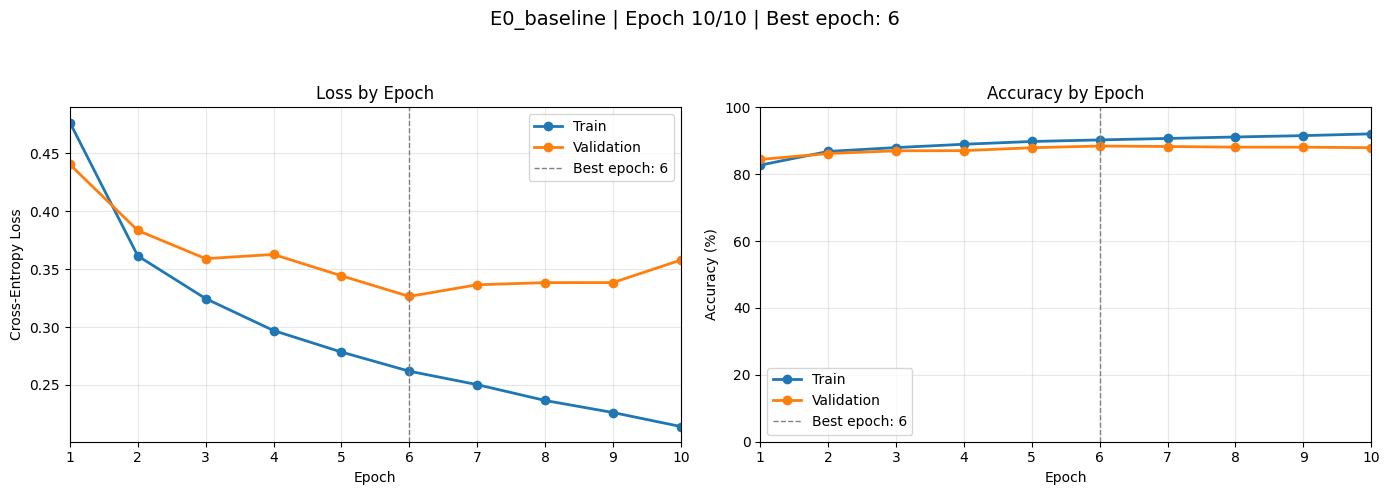

Running E1_deeper
Resuming E1_deeper after epoch 10/10


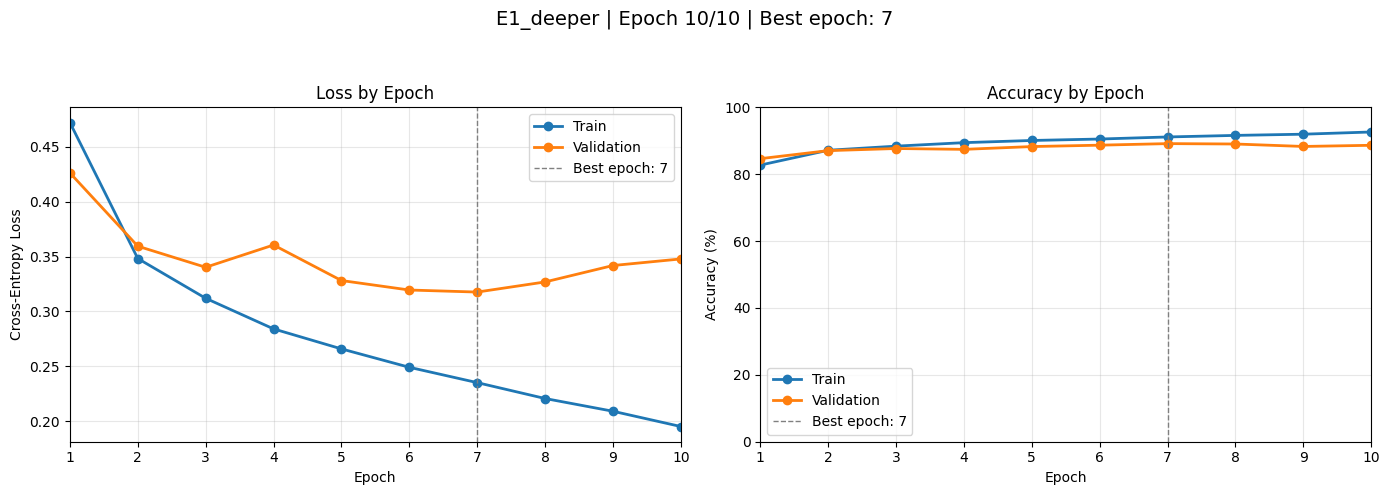

Running E2_dropout
Resuming E2_dropout after epoch 10/10


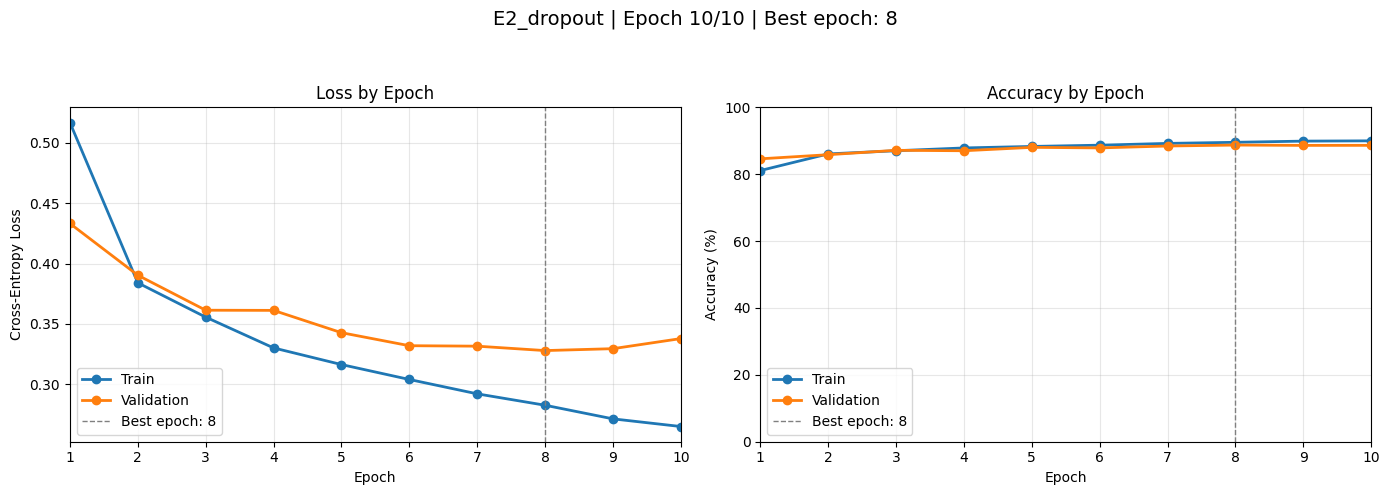

Running E3_sgd
Resuming E3_sgd after epoch 10/10


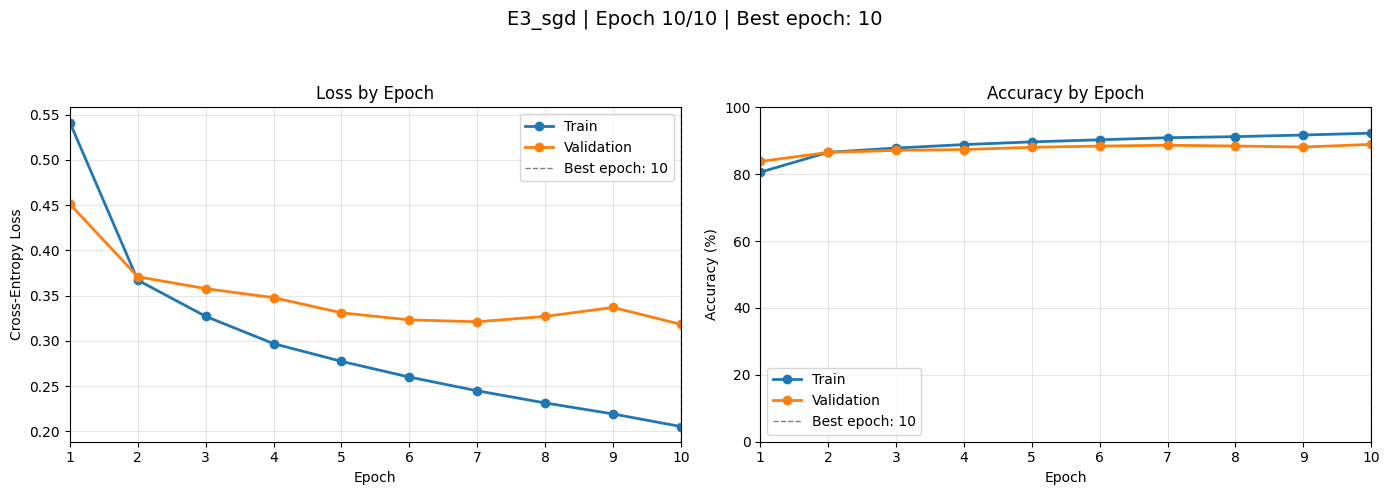

Running E4_augmentation
Resuming E4_augmentation after epoch 10/10


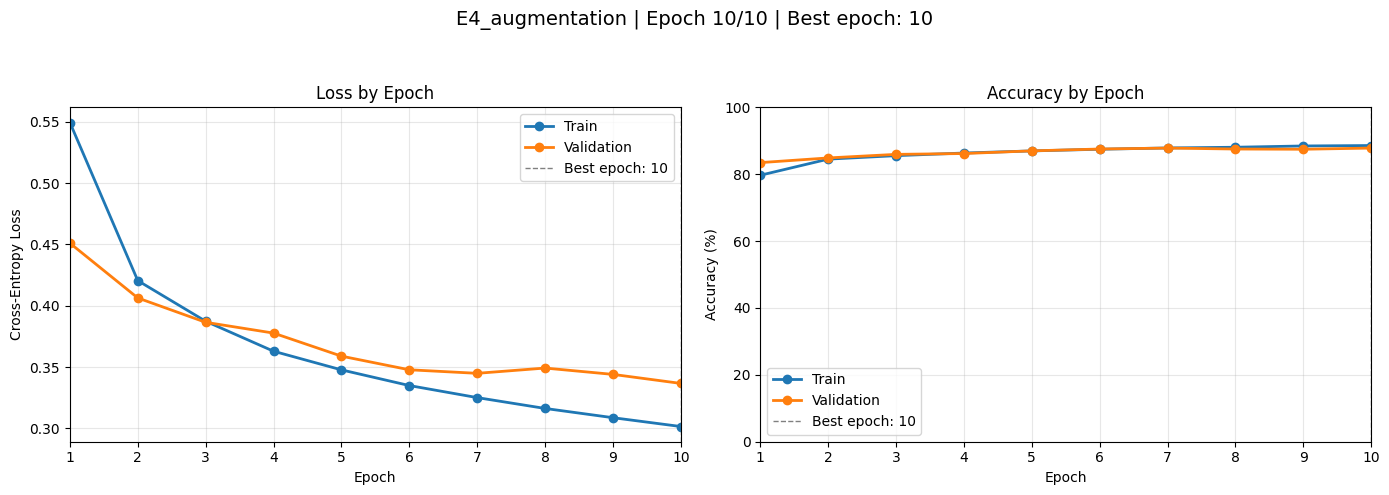

Selected experiment: E1_deeper
Best epoch: 7
Best validation accuracy: 89.15%
Running H_learning-rate_h256x128_lr1p000e-04_e20_s42 | lr=0.0001 | hidden=(256, 128)


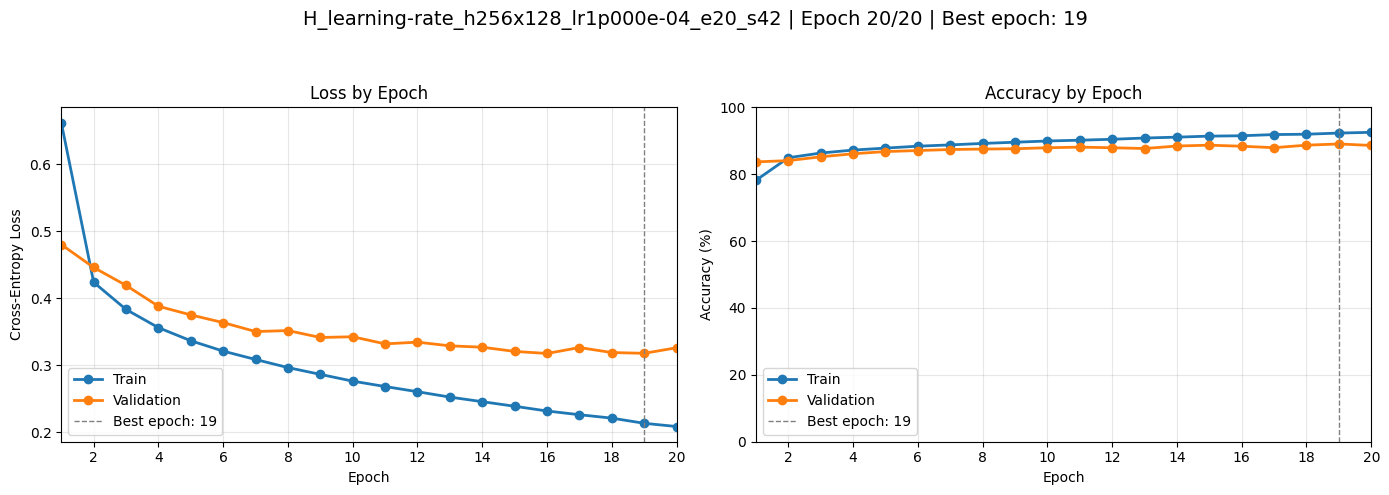

Epoch 01/20 | Train Loss 0.6624 | Train Accuracy 78.18% | Validation Loss 0.4803 | Validation Accuracy 83.68%


Epoch 02/20 | Train Loss 0.4240 | Train Accuracy 84.93% | Validation Loss 0.4461 | Validation Accuracy 84.07%


Epoch 03/20 | Train Loss 0.3834 | Train Accuracy 86.33% | Validation Loss 0.4194 | Validation Accuracy 85.20%


Epoch 04/20 | Train Loss 0.3563 | Train Accuracy 87.22% | Validation Loss 0.3882 | Validation Accuracy 86.12%


Epoch 05/20 | Train Loss 0.3367 | Train Accuracy 87.81% | Validation Loss 0.3753 | Validation Accuracy 86.77%


...

Epoch 17/20 | Train Loss 0.2263 | Train Accuracy 91.85% | Validation Loss 0.3266 | Validation Accuracy 87.93%


Epoch 18/20 | Train Loss 0.2213 | Train Accuracy 91.96% | Validation Loss 0.3191 | Validation Accuracy 88.68%


Epoch 19/20 | Train Loss 0.2135 | Train Accuracy 92.31% | Validation Loss 0.3180 | Validation Accuracy 89.05%


Epoch 20/20 | Train Loss 0.2087 | Train Accuracy 92.53% | Validation Loss 0.3263 | Validation Accuracy 88.60%


Running H_learning-rate_h256x128_lr3p000e-04_e20_s42 | lr=0.0003 | hidden=(256, 128)


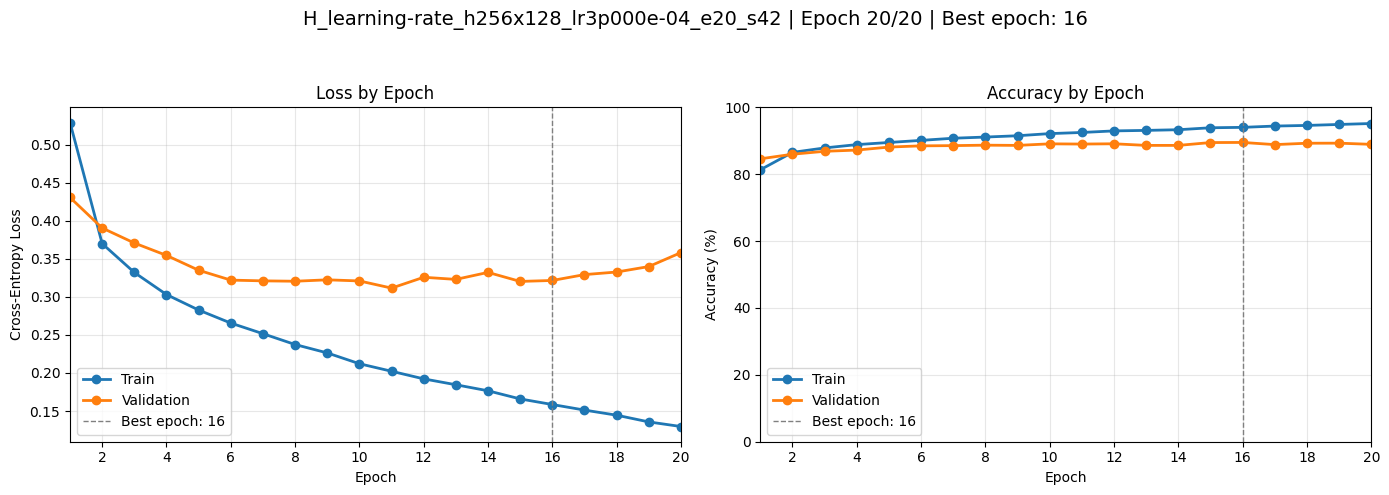

Epoch 01/20 | Train Loss 0.5292 | Train Accuracy 81.33% | Validation Loss 0.4307 | Validation Accuracy 84.60%


Epoch 02/20 | Train Loss 0.3700 | Train Accuracy 86.53% | Validation Loss 0.3905 | Validation Accuracy 85.98%


Epoch 03/20 | Train Loss 0.3321 | Train Accuracy 87.86% | Validation Loss 0.3708 | Validation Accuracy 86.85%


Epoch 04/20 | Train Loss 0.3031 | Train Accuracy 88.85% | Validation Loss 0.3545 | Validation Accuracy 87.22%


Epoch 05/20 | Train Loss 0.2827 | Train Accuracy 89.49% | Validation Loss 0.3350 | Validation Accuracy 88.12%


...

Epoch 17/20 | Train Loss 0.1512 | Train Accuracy 94.40% | Validation Loss 0.3293 | Validation Accuracy 88.85%


Epoch 18/20 | Train Loss 0.1445 | Train Accuracy 94.59% | Validation Loss 0.3327 | Validation Accuracy 89.27%


Epoch 19/20 | Train Loss 0.1357 | Train Accuracy 94.88% | Validation Loss 0.3399 | Validation Accuracy 89.28%


Epoch 20/20 | Train Loss 0.1296 | Train Accuracy 95.16% | Validation Loss 0.3582 | Validation Accuracy 88.93%


Running H_learning-rate_h256x128_lr1p000e-03_e20_s42 | lr=0.001 | hidden=(256, 128)


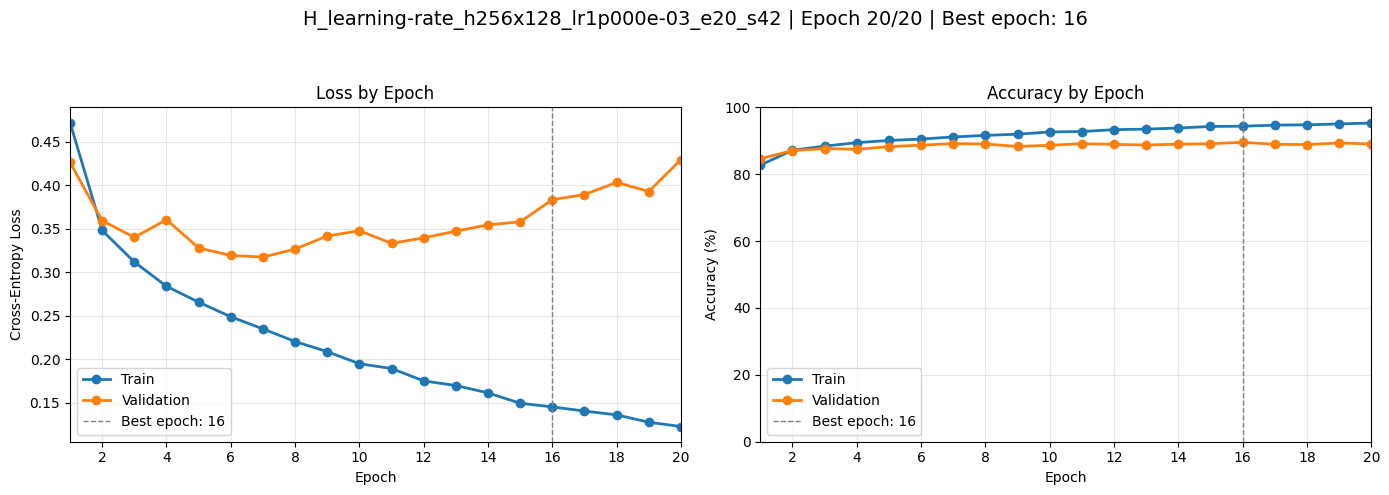

Epoch 01/20 | Train Loss 0.4722 | Train Accuracy 82.72% | Validation Loss 0.4263 | Validation Accuracy 84.65%


Epoch 02/20 | Train Loss 0.3482 | Train Accuracy 87.16% | Validation Loss 0.3595 | Validation Accuracy 87.05%


Epoch 03/20 | Train Loss 0.3120 | Train Accuracy 88.39% | Validation Loss 0.3403 | Validation Accuracy 87.68%


Epoch 04/20 | Train Loss 0.2841 | Train Accuracy 89.44% | Validation Loss 0.3606 | Validation Accuracy 87.43%


Epoch 05/20 | Train Loss 0.2658 | Train Accuracy 90.09% | Validation Loss 0.3282 | Validation Accuracy 88.27%


...

Epoch 17/20 | Train Loss 0.1407 | Train Accuracy 94.69% | Validation Loss 0.3895 | Validation Accuracy 88.95%


Epoch 18/20 | Train Loss 0.1363 | Train Accuracy 94.78% | Validation Loss 0.4035 | Validation Accuracy 88.87%


Epoch 19/20 | Train Loss 0.1279 | Train Accuracy 95.04% | Validation Loss 0.3930 | Validation Accuracy 89.33%


Epoch 20/20 | Train Loss 0.1230 | Train Accuracy 95.30% | Validation Loss 0.4296 | Validation Accuracy 89.03%


Running H_learning-rate_h256x128_lr3p000e-03_e20_s42 | lr=0.003 | hidden=(256, 128)


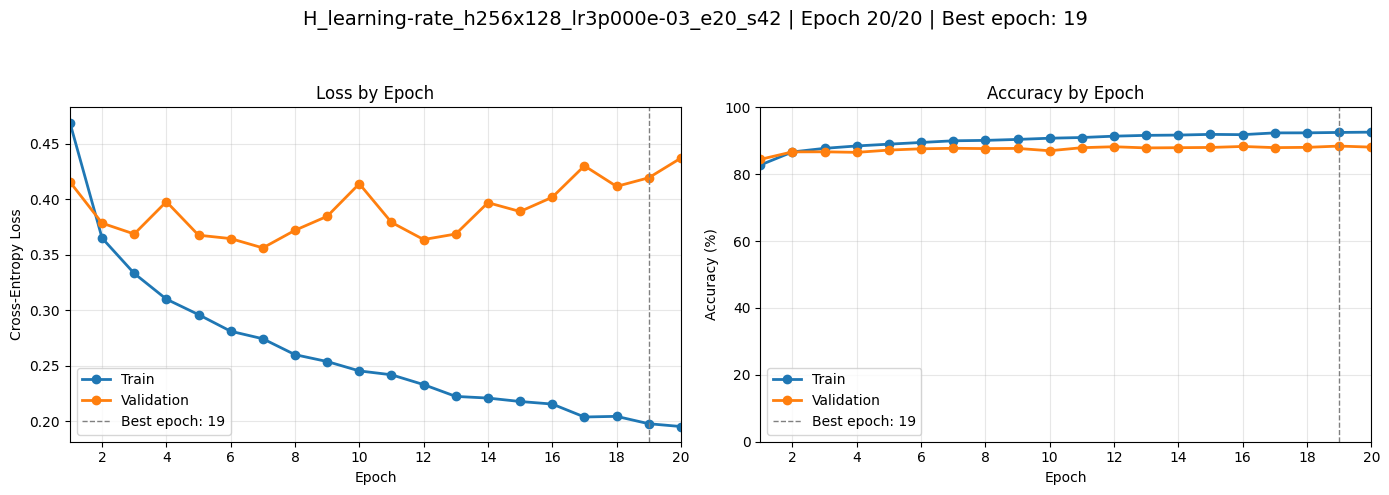

Epoch 01/20 | Train Loss 0.4690 | Train Accuracy 82.75% | Validation Loss 0.4156 | Validation Accuracy 84.43%


Epoch 02/20 | Train Loss 0.3650 | Train Accuracy 86.66% | Validation Loss 0.3785 | Validation Accuracy 86.68%


Epoch 03/20 | Train Loss 0.3332 | Train Accuracy 87.74% | Validation Loss 0.3687 | Validation Accuracy 86.70%


Epoch 04/20 | Train Loss 0.3100 | Train Accuracy 88.45% | Validation Loss 0.3978 | Validation Accuracy 86.53%


Epoch 05/20 | Train Loss 0.2961 | Train Accuracy 88.99% | Validation Loss 0.3676 | Validation Accuracy 87.22%


...

Epoch 17/20 | Train Loss 0.2039 | Train Accuracy 92.36% | Validation Loss 0.4300 | Validation Accuracy 87.95%


Epoch 18/20 | Train Loss 0.2045 | Train Accuracy 92.37% | Validation Loss 0.4115 | Validation Accuracy 88.03%


Epoch 19/20 | Train Loss 0.1979 | Train Accuracy 92.49% | Validation Loss 0.4193 | Validation Accuracy 88.42%


Epoch 20/20 | Train Loss 0.1954 | Train Accuracy 92.58% | Validation Loss 0.4370 | Validation Accuracy 88.10%


Stage A best learning rate: 0.001 | validation_accuracy=89.53% | validation_loss=0.3836


In [41]:
RUN_SESSION = time.strftime('%Y%m%d-%H%M%S')
RUN_ROOT = RUNS_DIR / RUN_SESSION
EXPERIMENT_OUTPUT_DIR = OUTPUT_DIR / 'experiments'
RECOVERY_OUTPUT_DIR = OUTPUT_DIR / 'recovery'
HYPERPARAMETER_SEARCH_DIR = OUTPUT_DIR / 'hyperparameter_search'
SEARCH_TRIAL_OUTPUT_DIR = HYPERPARAMETER_SEARCH_DIR / 'trials'
SEARCH_PLOT_OUTPUT_DIR = HYPERPARAMETER_SEARCH_DIR / 'plots'
SEARCH_RECOVERY_DIR = RECOVERY_OUTPUT_DIR / 'hyperparameter_search'
RUN_ROOT.mkdir(parents=True, exist_ok=True)
EXPERIMENT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RECOVERY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SEARCH_TRIAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SEARCH_PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SEARCH_RECOVERY_DIR.mkdir(parents=True, exist_ok=True)

ENABLE_LIVE_TRAINING_PLOTS = True
ENABLE_RECOVERY_CHECKPOINTS = True
RESUME_IF_AVAILABLE = True
TRAIN_INDEX_FINGERPRINT = fingerprint_indices(train_indices)
VALIDATION_INDEX_FINGERPRINT = fingerprint_indices(
    validation_indices
)
experiment_results = []

for experiment_config in EXPERIMENT_CONFIGS:
    experiment_id = experiment_config['experiment_id']
    experiment_dataset = (
        augmented_train_subset
        if experiment_config['use_augmentation']
        else train_subset
    )
    experiment_signature = build_checkpoint_signature({
        'contract': 'fashion-mnist-practice-1-experiment-v1',
        'config': experiment_config,
        'training_sample_count': len(experiment_dataset),
        'validation_sample_count': len(validation_subset),
        'train_indices': TRAIN_INDEX_FINGERPRINT,
        'validation_indices': VALIDATION_INDEX_FINGERPRINT,
        'train_mean': TRAIN_MEAN,
        'train_std': TRAIN_STD,
        'device_type': device.type,
        'torch_version': torch.__version__,
        'torchvision_version': torchvision.__version__,
    })
    experiment_checkpoint_manager = TrainingCheckpointManager(
        RECOVERY_OUTPUT_DIR / f'{experiment_id}.resume.pth',
        run_kind='experiment',
        run_id=experiment_id,
        signature=experiment_signature,
        enabled=ENABLE_RECOVERY_CHECKPOINTS,
    )
    print(f'Running {experiment_id}')
    experiment_monitor = TrainingMonitor(
        run_name=experiment_id,
        total_epochs=experiment_config['epochs'],
        include_validation=True,
        enabled=ENABLE_LIVE_TRAINING_PLOTS,
    )
    with experiment_monitor:
        result = run_training(
            experiment_config,
            experiment_dataset,
            validation_loader,
            device,
            log_directory=RUN_ROOT / experiment_id,
            monitor=experiment_monitor,
            checkpoint_manager=experiment_checkpoint_manager,
            resume_from_checkpoint=RESUME_IF_AVAILABLE,
        )
    experiment_results.append(result)
    atomic_torch_save(
        {
            'model_state_dict': clone_to_cpu(
                result['model'].state_dict()
            ),
            'config': result['config'],
            'best_epoch': result['best_epoch'],
            'best_validation_accuracy': (
                result['best_validation_accuracy']
            ),
            'best_validation_loss': result['best_validation_loss'],
            'history': result['history'],
            'parameter_count': result['parameter_count'],
            'training_sample_count': (
                result['training_sample_count']
            ),
            'total_seconds': result['total_seconds'],
            'resumed_from_epoch': result['resumed_from_epoch'],
            'recovery_checkpoint_path': (
                result['recovery_checkpoint_path']
            ),
        },
        EXPERIMENT_OUTPUT_DIR / f'{experiment_id}.pth',
    )

selected_result = max(
    experiment_results,
    key=lambda result: (
        result['best_validation_accuracy'],
        -result['best_validation_loss'],
    ),
)
selected_config = dict(selected_result['config'])
model = selected_result['model']
training_history = selected_result['history']

print(f"Selected experiment: {selected_result['experiment_id']}")
print(f"Best epoch: {selected_result['best_epoch']}")
print(
    'Best validation accuracy: '
    f"{selected_result['best_validation_accuracy']:.2%}"
)
controlled_selected_result = selected_result


def run_search_trials(trial_configs):
    trial_configs = list(trial_configs)
    if not trial_configs:
        raise ValueError('Search stage must contain at least one trial')
    trial_ids = [config['experiment_id'] for config in trial_configs]
    if len(trial_ids) != len(set(trial_ids)):
        raise ValueError('Search trial IDs must be unique within a stage')
    stage_results = []
    for trial_config in trial_configs:
        trial_id = trial_config['experiment_id']
        trial_stage = trial_config['search_stage']
        trial_dataset = (
            augmented_train_subset
            if trial_config['use_augmentation']
            else train_subset
        )
        trial_signature = build_checkpoint_signature({
            'contract': 'fashion-mnist-hyperparameter-search-v1',
            'config': trial_config,
            'training_sample_count': len(trial_dataset),
            'validation_sample_count': len(validation_subset),
            'train_indices': TRAIN_INDEX_FINGERPRINT,
            'validation_indices': VALIDATION_INDEX_FINGERPRINT,
            'train_mean': TRAIN_MEAN,
            'train_std': TRAIN_STD,
            'device_type': device.type,
            'torch_version': torch.__version__,
            'torchvision_version': torchvision.__version__,
        })
        checkpoint_manager = TrainingCheckpointManager(
            SEARCH_RECOVERY_DIR / f'{trial_id}.resume.pth',
            run_kind='hyperparameter-search',
            run_id=trial_id,
            signature=trial_signature,
            enabled=ENABLE_RECOVERY_CHECKPOINTS,
        )
        print(
            f"Running {trial_id} | lr={trial_config['learning_rate']:.6g} "
            f"| hidden={trial_config['hidden_dims']}"
        )
        trial_monitor = TrainingMonitor(
            run_name=trial_id,
            total_epochs=trial_config['epochs'],
            include_validation=True,
            enabled=ENABLE_LIVE_TRAINING_PLOTS,
            save_path=SEARCH_PLOT_OUTPUT_DIR / f'{trial_id}.png',
        )
        with trial_monitor:
            trial_result = run_training(
                trial_config,
                trial_dataset,
                validation_loader,
                device,
                log_directory=(
                    RUN_ROOT
                    / 'hyperparameter_search'
                    / trial_stage
                    / trial_id
                ),
                monitor=trial_monitor,
                checkpoint_manager=checkpoint_manager,
                resume_from_checkpoint=RESUME_IF_AVAILABLE,
            )
        stage_results.append(trial_result)
        atomic_torch_save(
            {
                'model_state_dict': clone_to_cpu(
                    trial_result['model'].state_dict()
                ),
                'config': trial_result['config'],
                'best_epoch': trial_result['best_epoch'],
                'best_validation_accuracy': (
                    trial_result['best_validation_accuracy']
                ),
                'best_validation_loss': (
                    trial_result['best_validation_loss']
                ),
                'history': trial_result['history'],
                'parameter_count': trial_result['parameter_count'],
                'training_sample_count': (
                    trial_result['training_sample_count']
                ),
                'total_seconds': trial_result['total_seconds'],
                'resumed_from_epoch': (
                    trial_result['resumed_from_epoch']
                ),
                'recovery_checkpoint_path': (
                    trial_result['recovery_checkpoint_path']
                ),
            },
            SEARCH_TRIAL_OUTPUT_DIR / f'{trial_id}.pth',
        )
    return stage_results


learning_rate_trial_configs = generate_learning_rate_trials(
    HYPERPARAMETER_BASE_CONFIG,
    LEARNING_RATE_CANDIDATES,
    hidden_dims=LEARNING_RATE_ANCHOR_DIMS,
    epochs=LEARNING_RATE_SEARCH_EPOCHS,
    seed=SEED,
)
learning_rate_results = run_search_trials(
    learning_rate_trial_configs
)
best_learning_rate_preview = rank_results(learning_rate_results)[0]
print(
    'Stage A best learning rate: '
    f"{best_learning_rate_preview['config']['learning_rate']:.6g} | "
    f"validation_accuracy="
    f"{best_learning_rate_preview['best_validation_accuracy']:.2%} | "
    f"validation_loss="
    f"{best_learning_rate_preview['best_validation_loss']:.4f}"
)

### Experiment Results

The comparison table reports the best validation checkpoint from every fresh run. Parameter count and runtime make the accuracy trade-off visible. Only the selected experiment proceeds to final retraining and official test evaluation.

E0_baseline: validation_accuracy=88.43%, validation_loss=0.3265, best_epoch=6, parameters=101,770, seconds=43.5
E1_deeper: validation_accuracy=89.15%, validation_loss=0.3177, best_epoch=7, parameters=235,146, seconds=46.9
E2_dropout: validation_accuracy=88.72%, validation_loss=0.3279, best_epoch=8, parameters=235,146, seconds=45.8
E3_sgd: validation_accuracy=88.93%, validation_loss=0.3183, best_epoch=10, parameters=235,146, seconds=42.0
E4_augmentation: validation_accuracy=87.82%, validation_loss=0.3366, best_epoch=10, parameters=235,146, seconds=59.3
Stage A learning-rate ranking:
1. lr=0.001 | validation_accuracy=89.53% | validation_loss=0.3836 | best_epoch=16
2. lr=0.0003 | validation_accuracy=89.50% | validation_loss=0.3216 | best_epoch=16
3. lr=0.0001 | validation_accuracy=89.05% | validation_loss=0.3180 | best_epoch=19
4. lr=0.003 | validation_accuracy=88.42% | validation_loss=0.4193 | best_epoch=19
Running H_architecture_h256_lr1p000e-03_e25_s42 | lr=0.001 | hidden=(256,)


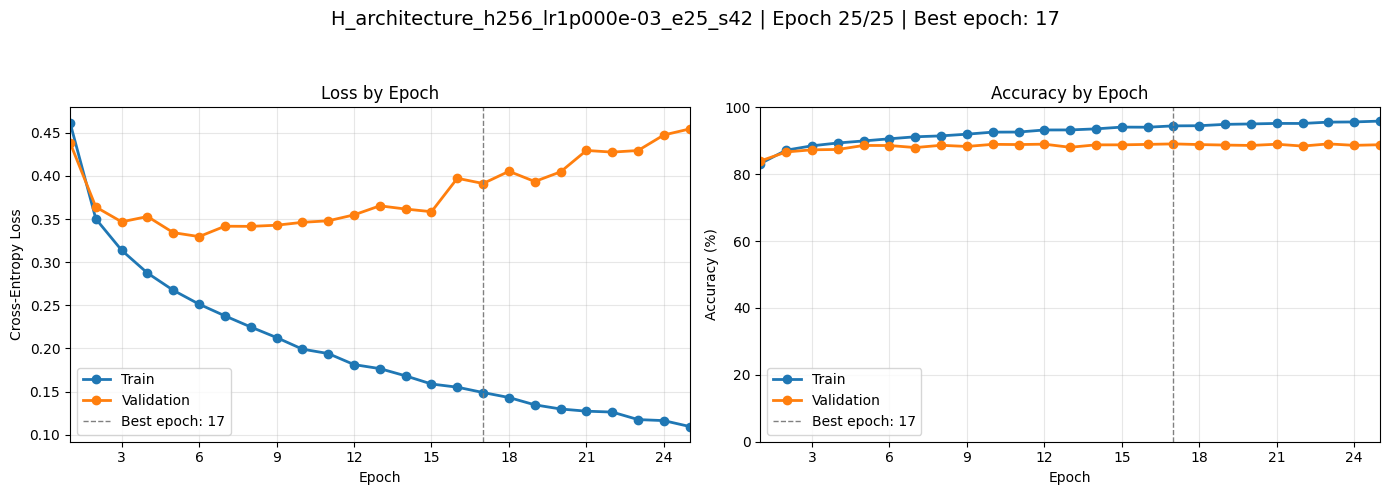

Epoch 01/25 | Train Loss 0.4619 | Train Accuracy 83.17% | Validation Loss 0.4386 | Validation Accuracy 83.95%


Epoch 02/25 | Train Loss 0.3502 | Train Accuracy 87.19% | Validation Loss 0.3639 | Validation Accuracy 86.65%


Epoch 03/25 | Train Loss 0.3138 | Train Accuracy 88.50% | Validation Loss 0.3468 | Validation Accuracy 87.30%


Epoch 04/25 | Train Loss 0.2874 | Train Accuracy 89.34% | Validation Loss 0.3529 | Validation Accuracy 87.40%


Epoch 05/25 | Train Loss 0.2674 | Train Accuracy 89.95% | Validation Loss 0.3342 | Validation Accuracy 88.60%


...

Epoch 22/25 | Train Loss 0.1262 | Train Accuracy 95.18% | Validation Loss 0.4276 | Validation Accuracy 88.42%


Epoch 23/25 | Train Loss 0.1175 | Train Accuracy 95.58% | Validation Loss 0.4295 | Validation Accuracy 89.07%


Epoch 24/25 | Train Loss 0.1163 | Train Accuracy 95.63% | Validation Loss 0.4475 | Validation Accuracy 88.63%


Epoch 25/25 | Train Loss 0.1094 | Train Accuracy 95.88% | Validation Loss 0.4545 | Validation Accuracy 88.82%


Running H_architecture_h256x128_lr1p000e-03_e25_s42 | lr=0.001 | hidden=(256, 128)


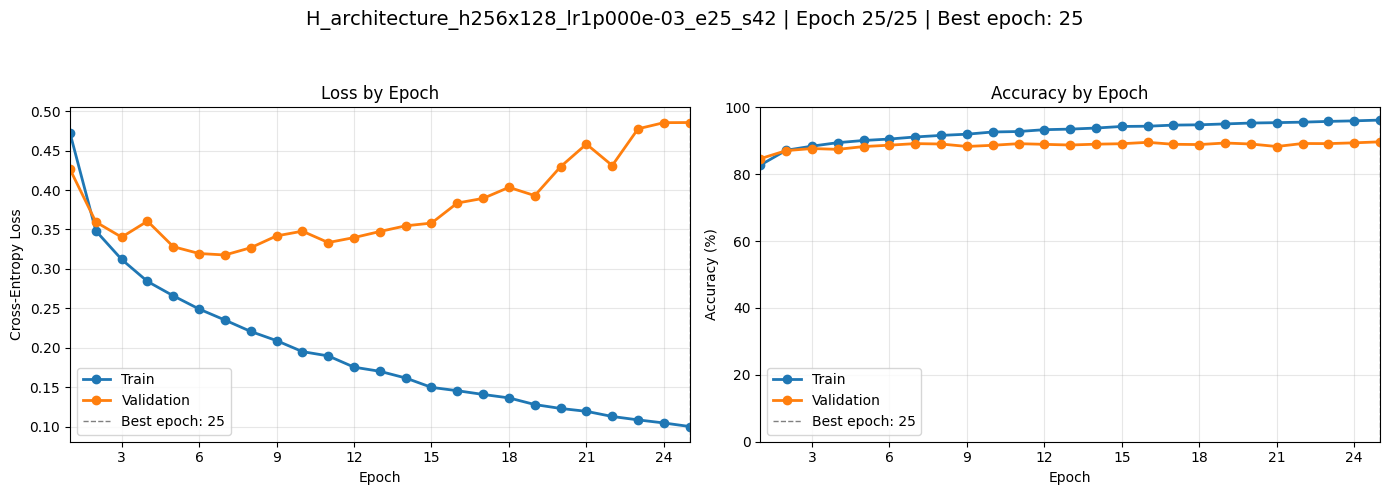

Epoch 01/25 | Train Loss 0.4722 | Train Accuracy 82.72% | Validation Loss 0.4263 | Validation Accuracy 84.65%


Epoch 02/25 | Train Loss 0.3482 | Train Accuracy 87.16% | Validation Loss 0.3595 | Validation Accuracy 87.05%


Epoch 03/25 | Train Loss 0.3120 | Train Accuracy 88.39% | Validation Loss 0.3403 | Validation Accuracy 87.68%


Epoch 04/25 | Train Loss 0.2841 | Train Accuracy 89.44% | Validation Loss 0.3606 | Validation Accuracy 87.43%


Epoch 05/25 | Train Loss 0.2658 | Train Accuracy 90.09% | Validation Loss 0.3282 | Validation Accuracy 88.27%


...

Epoch 22/25 | Train Loss 0.1128 | Train Accuracy 95.57% | Validation Loss 0.4312 | Validation Accuracy 89.18%


Epoch 23/25 | Train Loss 0.1084 | Train Accuracy 95.79% | Validation Loss 0.4777 | Validation Accuracy 89.15%


Epoch 24/25 | Train Loss 0.1045 | Train Accuracy 95.96% | Validation Loss 0.4855 | Validation Accuracy 89.38%


Epoch 25/25 | Train Loss 0.1000 | Train Accuracy 96.19% | Validation Loss 0.4857 | Validation Accuracy 89.68%


Running H_architecture_h256x128x64_lr1p000e-03_e25_s42 | lr=0.001 | hidden=(256, 128, 64)


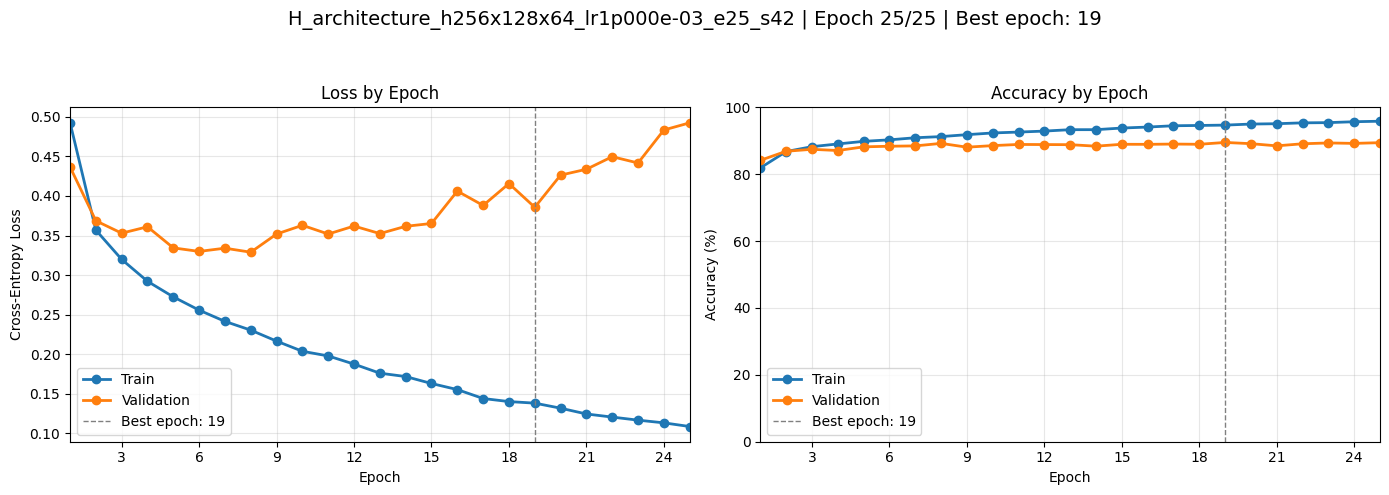

Epoch 01/25 | Train Loss 0.4928 | Train Accuracy 81.89% | Validation Loss 0.4368 | Validation Accuracy 84.15%


Epoch 02/25 | Train Loss 0.3569 | Train Accuracy 86.78% | Validation Loss 0.3687 | Validation Accuracy 86.87%


Epoch 03/25 | Train Loss 0.3199 | Train Accuracy 88.24% | Validation Loss 0.3530 | Validation Accuracy 87.45%


Epoch 04/25 | Train Loss 0.2922 | Train Accuracy 89.05% | Validation Loss 0.3611 | Validation Accuracy 87.08%


Epoch 05/25 | Train Loss 0.2725 | Train Accuracy 89.83% | Validation Loss 0.3344 | Validation Accuracy 88.18%


...

Epoch 22/25 | Train Loss 0.1206 | Train Accuracy 95.36% | Validation Loss 0.4497 | Validation Accuracy 89.10%


Epoch 23/25 | Train Loss 0.1168 | Train Accuracy 95.43% | Validation Loss 0.4417 | Validation Accuracy 89.35%


Epoch 24/25 | Train Loss 0.1133 | Train Accuracy 95.70% | Validation Loss 0.4834 | Validation Accuracy 89.22%


Epoch 25/25 | Train Loss 0.1087 | Train Accuracy 95.85% | Validation Loss 0.4924 | Validation Accuracy 89.43%


Running H_architecture_h256x128x64x32_lr1p000e-03_e25_s42 | lr=0.001 | hidden=(256, 128, 64, 32)


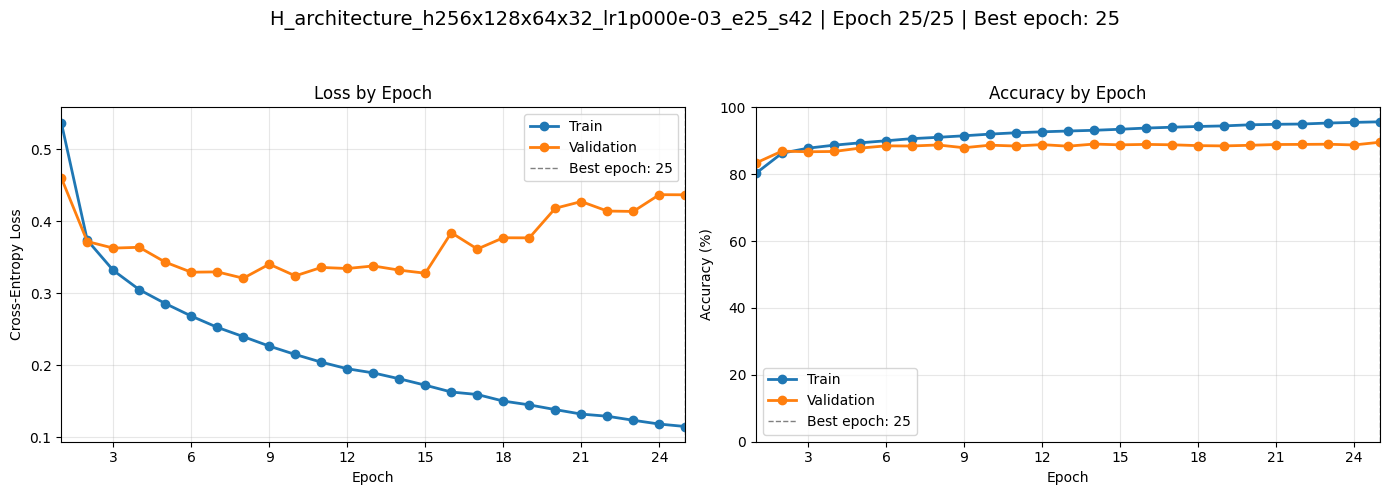

Epoch 01/25 | Train Loss 0.5372 | Train Accuracy 80.28% | Validation Loss 0.4605 | Validation Accuracy 83.37%


Epoch 02/25 | Train Loss 0.3738 | Train Accuracy 86.29% | Validation Loss 0.3720 | Validation Accuracy 86.90%


Epoch 03/25 | Train Loss 0.3319 | Train Accuracy 87.79% | Validation Loss 0.3629 | Validation Accuracy 86.72%


Epoch 04/25 | Train Loss 0.3052 | Train Accuracy 88.68% | Validation Loss 0.3640 | Validation Accuracy 86.80%


Epoch 05/25 | Train Loss 0.2859 | Train Accuracy 89.38% | Validation Loss 0.3433 | Validation Accuracy 87.80%


...

Epoch 22/25 | Train Loss 0.1294 | Train Accuracy 95.01% | Validation Loss 0.4143 | Validation Accuracy 88.92%


Epoch 23/25 | Train Loss 0.1238 | Train Accuracy 95.31% | Validation Loss 0.4138 | Validation Accuracy 88.97%


Epoch 24/25 | Train Loss 0.1185 | Train Accuracy 95.50% | Validation Loss 0.4371 | Validation Accuracy 88.75%


Epoch 25/25 | Train Loss 0.1151 | Train Accuracy 95.67% | Validation Loss 0.4369 | Validation Accuracy 89.57%


Running H_architecture_h512x256x128_lr1p000e-03_e25_s42 | lr=0.001 | hidden=(512, 256, 128)


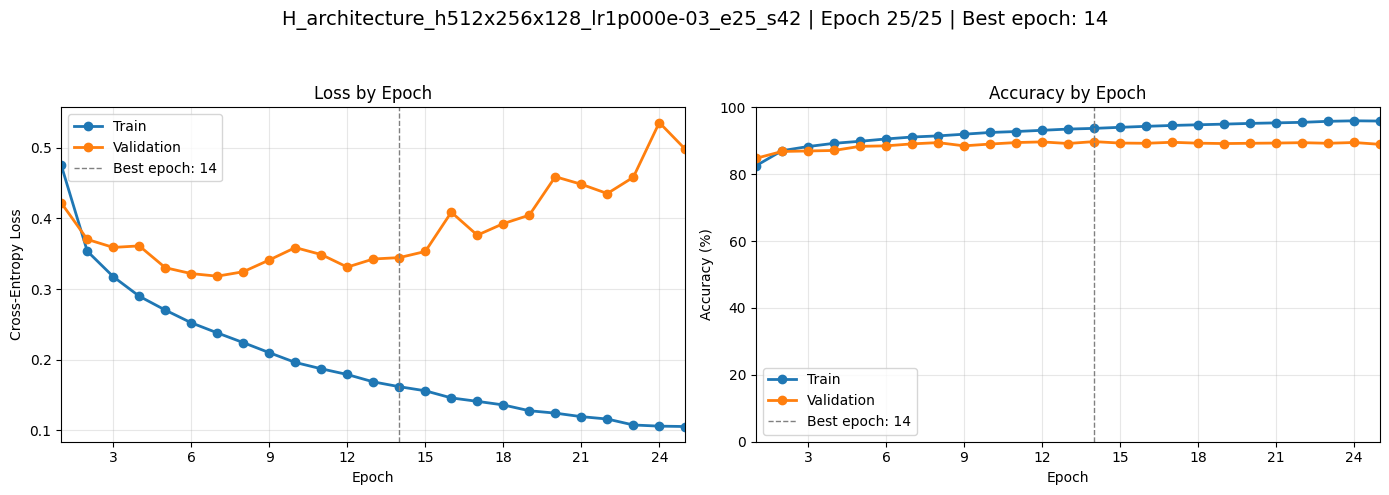

Epoch 01/25 | Train Loss 0.4751 | Train Accuracy 82.52% | Validation Loss 0.4218 | Validation Accuracy 84.75%


Epoch 02/25 | Train Loss 0.3535 | Train Accuracy 87.03% | Validation Loss 0.3702 | Validation Accuracy 86.80%


Epoch 03/25 | Train Loss 0.3174 | Train Accuracy 88.27% | Validation Loss 0.3589 | Validation Accuracy 86.95%


Epoch 04/25 | Train Loss 0.2898 | Train Accuracy 89.24% | Validation Loss 0.3610 | Validation Accuracy 87.10%


Epoch 05/25 | Train Loss 0.2702 | Train Accuracy 89.85% | Validation Loss 0.3302 | Validation Accuracy 88.33%


...

Epoch 22/25 | Train Loss 0.1160 | Train Accuracy 95.51% | Validation Loss 0.4352 | Validation Accuracy 89.43%


Epoch 23/25 | Train Loss 0.1075 | Train Accuracy 95.82% | Validation Loss 0.4582 | Validation Accuracy 89.25%


Epoch 24/25 | Train Loss 0.1059 | Train Accuracy 95.97% | Validation Loss 0.5356 | Validation Accuracy 89.48%


Epoch 25/25 | Train Loss 0.1053 | Train Accuracy 95.90% | Validation Loss 0.4978 | Validation Accuracy 88.93%


Stage B best hidden dimensions: (512, 256, 128) | validation_accuracy=89.75% | validation_loss=0.3444


In [42]:
controlled_experiment_summary = [
    {
        'experiment_id': result['experiment_id'],
        'hidden_dims': result['config']['hidden_dims'],
        'dropout': result['config']['dropout'],
        'optimizer': result['config']['optimizer'],
        'learning_rate': result['config']['learning_rate'],
        'augmentation': result['config']['use_augmentation'],
        'parameters': result['parameter_count'],
        'best_epoch': result['best_epoch'],
        'validation_loss': result['best_validation_loss'],
        'validation_accuracy': result['best_validation_accuracy'],
        'seconds': result['total_seconds'],
    }
    for result in experiment_results
]

for row in controlled_experiment_summary:
    print(
        f"{row['experiment_id']}: "
        f"validation_accuracy={row['validation_accuracy']:.2%}, "
        f"validation_loss={row['validation_loss']:.4f}, "
        f"best_epoch={row['best_epoch']}, "
        f"parameters={row['parameters']:,}, "
        f"seconds={row['seconds']:.1f}"
    )

learning_rate_ranking = rank_results(learning_rate_results)
best_learning_rate_result = learning_rate_ranking[0]
best_coarse_learning_rate = (
    best_learning_rate_result['config']['learning_rate']
)
print('Stage A learning-rate ranking:')
for rank, result in enumerate(learning_rate_ranking, start=1):
    print(
        f"{rank}. lr={result['config']['learning_rate']:.6g} | "
        f"validation_accuracy="
        f"{result['best_validation_accuracy']:.2%} | "
        f"validation_loss={result['best_validation_loss']:.4f} | "
        f"best_epoch={result['best_epoch']}"
    )

architecture_trial_configs = generate_architecture_trials(
    HYPERPARAMETER_BASE_CONFIG,
    HIDDEN_DIM_CANDIDATES,
    learning_rate=best_coarse_learning_rate,
    epochs=ARCHITECTURE_SEARCH_EPOCHS,
    seed=SEED,
)
architecture_results = run_search_trials(
    architecture_trial_configs
)
best_architecture_preview = rank_results(architecture_results)[0]
print(
    'Stage B best hidden dimensions: '
    f"{best_architecture_preview['config']['hidden_dims']} | "
    f"validation_accuracy="
    f"{best_architecture_preview['best_validation_accuracy']:.2%} | "
    f"validation_loss="
    f"{best_architecture_preview['best_validation_loss']:.4f}"
)

Running H_refinement_h512x256x128_lr5p774e-04_e25_s42 | lr=0.00057735 | hidden=(512, 256, 128)


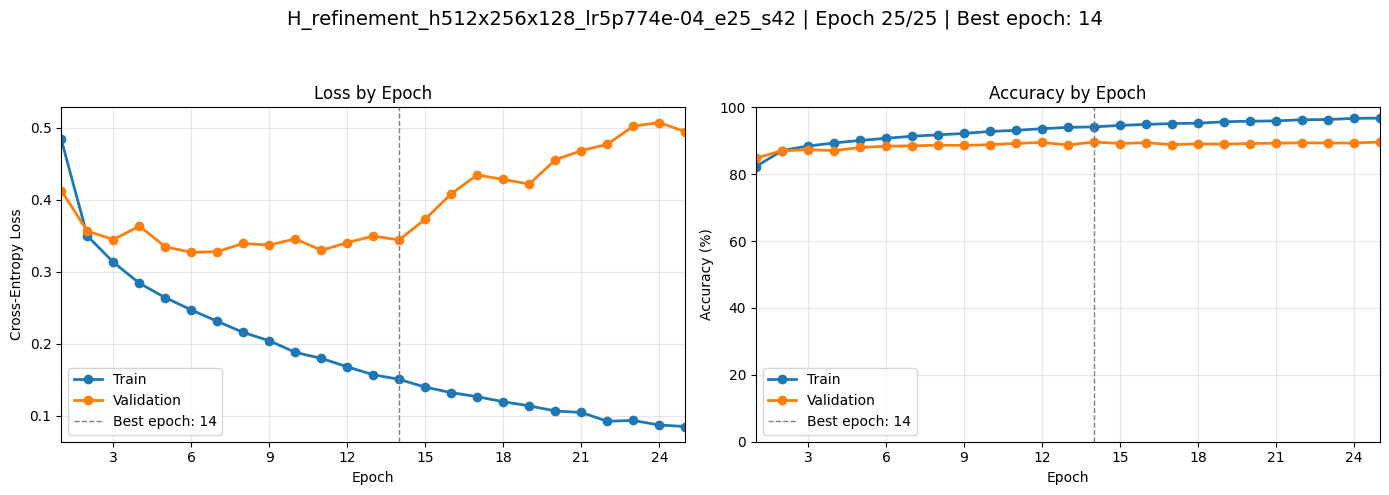

Epoch 01/25 | Train Loss 0.4840 | Train Accuracy 82.30% | Validation Loss 0.4130 | Validation Accuracy 84.82%


Epoch 02/25 | Train Loss 0.3501 | Train Accuracy 87.05% | Validation Loss 0.3567 | Validation Accuracy 87.03%


Epoch 03/25 | Train Loss 0.3135 | Train Accuracy 88.43% | Validation Loss 0.3448 | Validation Accuracy 87.35%


Epoch 04/25 | Train Loss 0.2843 | Train Accuracy 89.33% | Validation Loss 0.3636 | Validation Accuracy 87.05%


Epoch 05/25 | Train Loss 0.2643 | Train Accuracy 90.11% | Validation Loss 0.3350 | Validation Accuracy 88.00%


...

Epoch 22/25 | Train Loss 0.0926 | Train Accuracy 96.29% | Validation Loss 0.4772 | Validation Accuracy 89.38%


Epoch 23/25 | Train Loss 0.0936 | Train Accuracy 96.36% | Validation Loss 0.5024 | Validation Accuracy 89.33%


Epoch 24/25 | Train Loss 0.0873 | Train Accuracy 96.70% | Validation Loss 0.5075 | Validation Accuracy 89.30%


Epoch 25/25 | Train Loss 0.0852 | Train Accuracy 96.78% | Validation Loss 0.4946 | Validation Accuracy 89.63%


Running H_refinement_h512x256x128_lr1p732e-03_e25_s42 | lr=0.00173205 | hidden=(512, 256, 128)


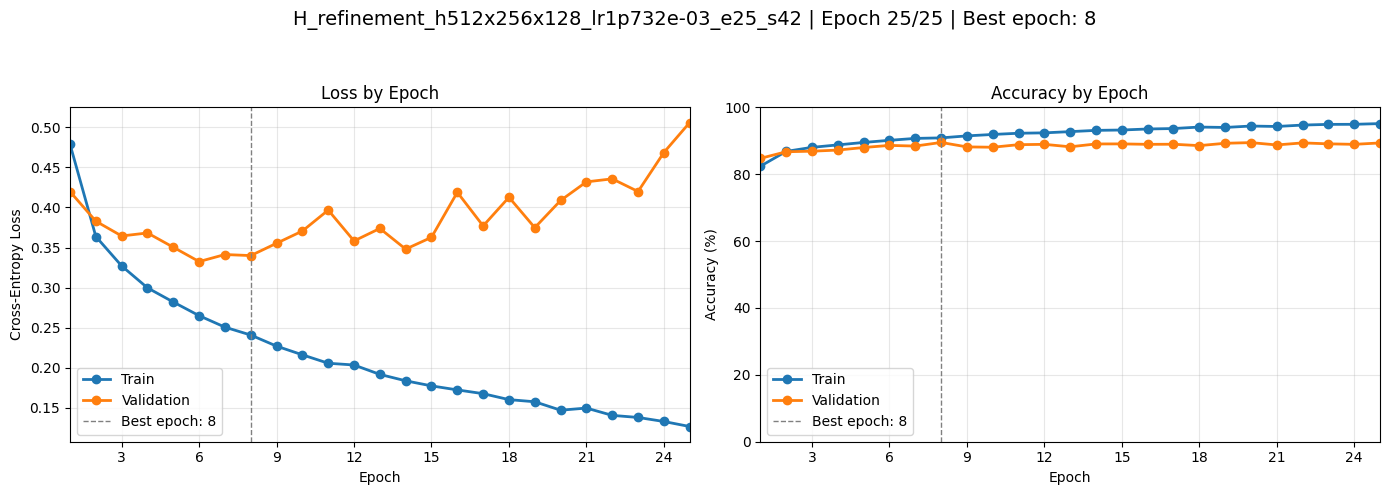

Epoch 01/25 | Train Loss 0.4789 | Train Accuracy 82.38% | Validation Loss 0.4198 | Validation Accuracy 84.73%


Epoch 02/25 | Train Loss 0.3637 | Train Accuracy 86.82% | Validation Loss 0.3829 | Validation Accuracy 86.72%


Epoch 03/25 | Train Loss 0.3270 | Train Accuracy 88.03% | Validation Loss 0.3644 | Validation Accuracy 86.88%


Epoch 04/25 | Train Loss 0.2997 | Train Accuracy 88.76% | Validation Loss 0.3682 | Validation Accuracy 87.22%


Epoch 05/25 | Train Loss 0.2820 | Train Accuracy 89.50% | Validation Loss 0.3504 | Validation Accuracy 87.98%


...

Epoch 22/25 | Train Loss 0.1405 | Train Accuracy 94.70% | Validation Loss 0.4358 | Validation Accuracy 89.37%


Epoch 23/25 | Train Loss 0.1379 | Train Accuracy 94.90% | Validation Loss 0.4199 | Validation Accuracy 89.08%


Epoch 24/25 | Train Loss 0.1329 | Train Accuracy 94.92% | Validation Loss 0.4686 | Validation Accuracy 88.93%


Epoch 25/25 | Train Loss 0.1266 | Train Accuracy 95.14% | Validation Loss 0.5060 | Validation Accuracy 89.35%


Stage B architecture ranking:
1. hidden=(512, 256, 128) | validation_accuracy=89.75% | validation_loss=0.3444
2. hidden=(256, 128) | validation_accuracy=89.68% | validation_loss=0.4857
3. hidden=(256, 128, 64, 32) | validation_accuracy=89.57% | validation_loss=0.4369
4. hidden=(256, 128, 64) | validation_accuracy=89.50% | validation_loss=0.3857
5. hidden=(256,) | validation_accuracy=89.07% | validation_loss=0.3912
Stage C refinement ranking:
1. lr=0.00057735 | validation_accuracy=89.65% | validation_loss=0.3444
2. lr=0.00173205 | validation_accuracy=89.50% | validation_loss=0.3400


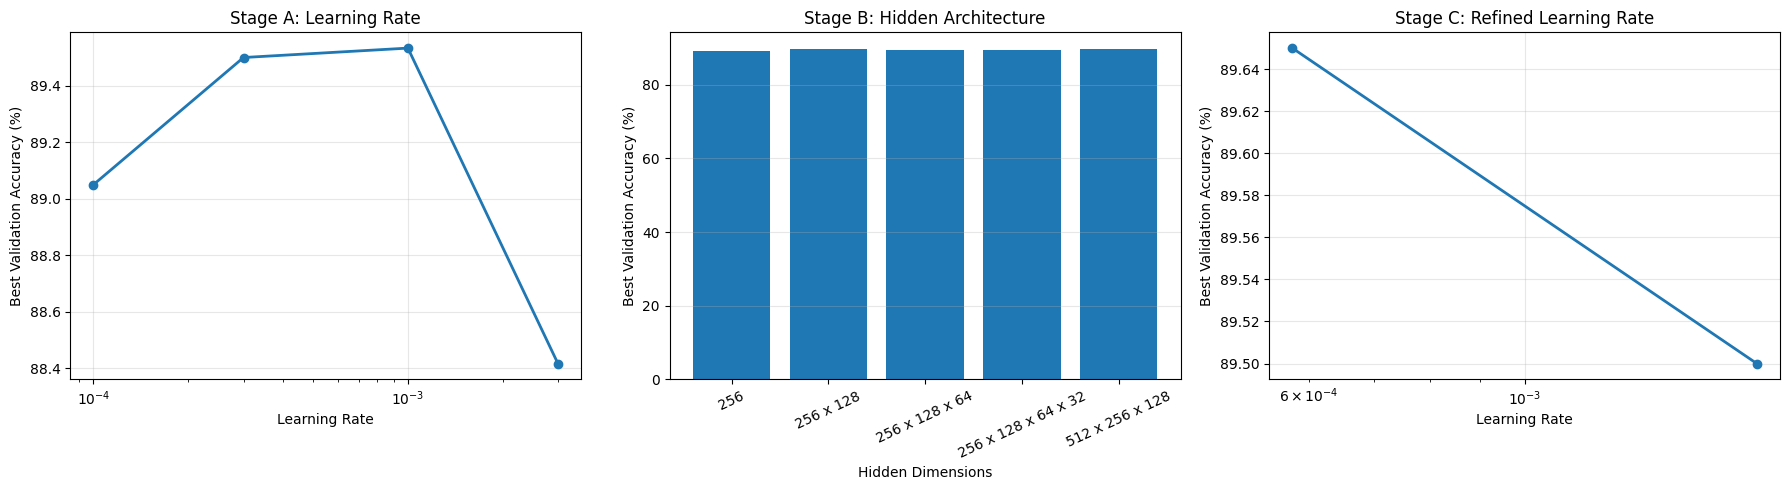

In [43]:
architecture_ranking = rank_results(architecture_results)
best_architecture_result = architecture_ranking[0]
best_hidden_dims = best_architecture_result['config']['hidden_dims']
refined_learning_rates = refinement_learning_rates(
    best_coarse_learning_rate
)
refinement_trial_configs = generate_learning_rate_trials(
    HYPERPARAMETER_BASE_CONFIG,
    refined_learning_rates,
    hidden_dims=best_hidden_dims,
    epochs=REFINEMENT_SEARCH_EPOCHS,
    seed=SEED,
    stage='refinement',
)
refinement_trial_configs = [
    config
    for config in refinement_trial_configs
    if config['candidate_key']
    != best_architecture_result['config']['candidate_key']
]
refinement_results = run_search_trials(refinement_trial_configs)
candidate_ranking = rank_results(
    architecture_results + refinement_results
)
top_candidate_results = []
seen_candidate_keys = set()
for result in candidate_ranking:
    result_candidate_key = result['config']['candidate_key']
    if result_candidate_key in seen_candidate_keys:
        continue
    top_candidate_results.append(result)
    seen_candidate_keys.add(result_candidate_key)
    if len(top_candidate_results) == CONFIRMATION_CANDIDATE_COUNT:
        break

print('Stage B architecture ranking:')
for rank, result in enumerate(architecture_ranking, start=1):
    print(
        f"{rank}. hidden={result['config']['hidden_dims']} | "
        f"validation_accuracy="
        f"{result['best_validation_accuracy']:.2%} | "
        f"validation_loss={result['best_validation_loss']:.4f}"
    )

print('Stage C refinement ranking:')
for rank, result in enumerate(
    rank_results(refinement_results),
    start=1,
):
    print(
        f"{rank}. lr={result['config']['learning_rate']:.6g} | "
        f"validation_accuracy="
        f"{result['best_validation_accuracy']:.2%} | "
        f"validation_loss={result['best_validation_loss']:.4f}"
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
learning_rate_plot_results = sorted(
    learning_rate_results,
    key=lambda result: result['config']['learning_rate'],
)
axes[0].plot(
    [result['config']['learning_rate'] for result in learning_rate_plot_results],
    [result['best_validation_accuracy'] * 100 for result in learning_rate_plot_results],
    marker='o',
    linewidth=2,
)
axes[0].set_xscale('log')
axes[0].set_title('Stage A: Learning Rate')
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('Best Validation Accuracy (%)')
axes[0].grid(True, alpha=0.3)

architecture_labels = [
    ' x '.join(str(width) for width in result['config']['hidden_dims'])
    for result in architecture_results
]
axes[1].bar(
    architecture_labels,
    [result['best_validation_accuracy'] * 100 for result in architecture_results],
)
axes[1].set_title('Stage B: Hidden Architecture')
axes[1].set_xlabel('Hidden Dimensions')
axes[1].set_ylabel('Best Validation Accuracy (%)')
axes[1].tick_params(axis='x', rotation=25)
axes[1].grid(axis='y', alpha=0.3)

refinement_plot_results = sorted(
    refinement_results,
    key=lambda result: result['config']['learning_rate'],
)
axes[2].plot(
    [result['config']['learning_rate'] for result in refinement_plot_results],
    [result['best_validation_accuracy'] * 100 for result in refinement_plot_results],
    marker='o',
    linewidth=2,
)
axes[2].set_xscale('log')
axes[2].set_title('Stage C: Refined Learning Rate')
axes[2].set_xlabel('Learning Rate')
axes[2].set_ylabel('Best Validation Accuracy (%)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(
    SEARCH_PLOT_OUTPUT_DIR / 'staged_search_comparison.png',
    dpi=150,
    bbox_inches='tight',
)
plt.show()

Running H_confirmation_h512x256x128_lr1p000e-03_e40_s42 | lr=0.001 | hidden=(512, 256, 128)


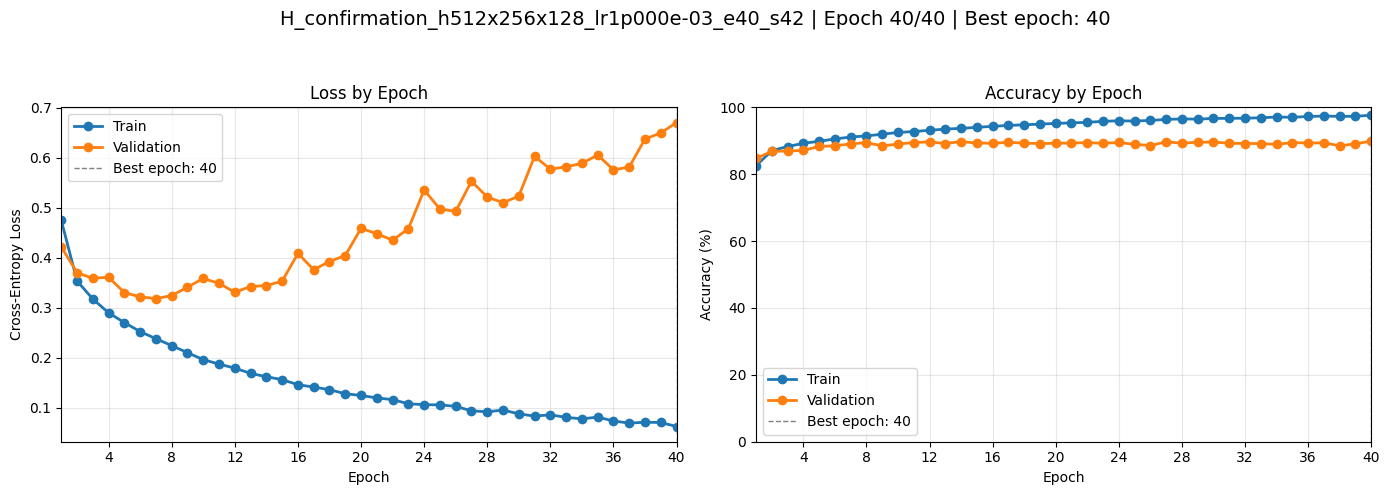

Epoch 01/40 | Train Loss 0.4751 | Train Accuracy 82.52% | Validation Loss 0.4218 | Validation Accuracy 84.75%


Epoch 02/40 | Train Loss 0.3535 | Train Accuracy 87.03% | Validation Loss 0.3702 | Validation Accuracy 86.80%


Epoch 03/40 | Train Loss 0.3174 | Train Accuracy 88.27% | Validation Loss 0.3589 | Validation Accuracy 86.95%


Epoch 04/40 | Train Loss 0.2898 | Train Accuracy 89.24% | Validation Loss 0.3610 | Validation Accuracy 87.10%


Epoch 05/40 | Train Loss 0.2702 | Train Accuracy 89.85% | Validation Loss 0.3302 | Validation Accuracy 88.33%


...

Epoch 37/40 | Train Loss 0.0689 | Train Accuracy 97.40% | Validation Loss 0.5817 | Validation Accuracy 89.38%


Epoch 38/40 | Train Loss 0.0707 | Train Accuracy 97.30% | Validation Loss 0.6380 | Validation Accuracy 88.50%


Epoch 39/40 | Train Loss 0.0701 | Train Accuracy 97.32% | Validation Loss 0.6500 | Validation Accuracy 89.10%


Epoch 40/40 | Train Loss 0.0620 | Train Accuracy 97.64% | Validation Loss 0.6709 | Validation Accuracy 89.88%


Running H_confirmation_h512x256x128_lr1p000e-03_e40_s123 | lr=0.001 | hidden=(512, 256, 128)


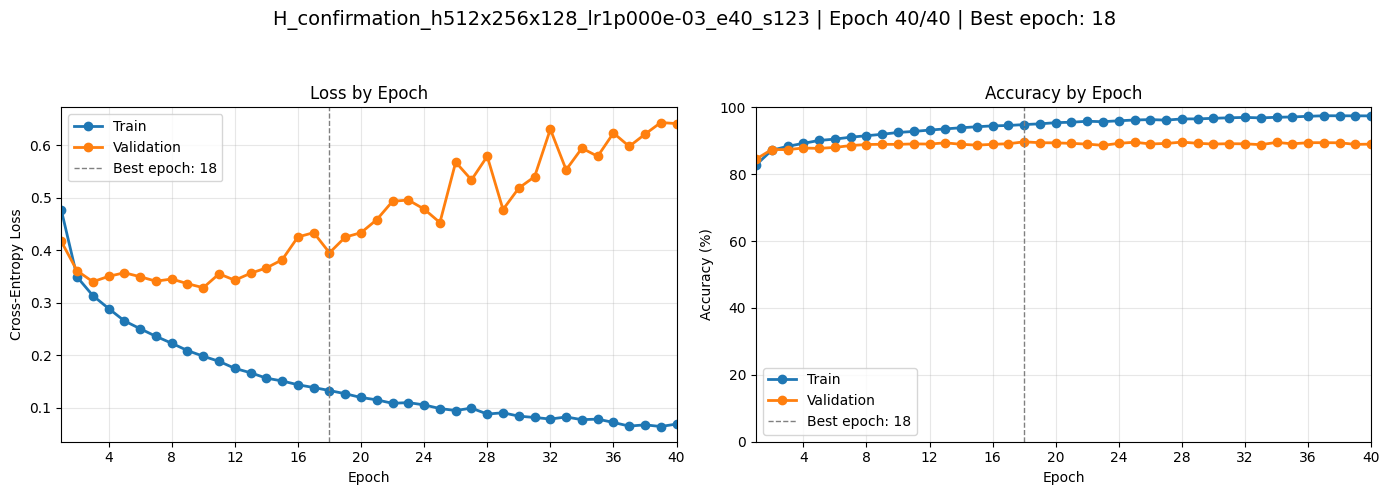

Epoch 01/40 | Train Loss 0.4766 | Train Accuracy 82.76% | Validation Loss 0.4167 | Validation Accuracy 84.50%


Epoch 02/40 | Train Loss 0.3491 | Train Accuracy 87.16% | Validation Loss 0.3609 | Validation Accuracy 87.38%


Epoch 03/40 | Train Loss 0.3137 | Train Accuracy 88.33% | Validation Loss 0.3400 | Validation Accuracy 87.35%


Epoch 04/40 | Train Loss 0.2891 | Train Accuracy 89.23% | Validation Loss 0.3503 | Validation Accuracy 87.83%


Epoch 05/40 | Train Loss 0.2655 | Train Accuracy 90.10% | Validation Loss 0.3571 | Validation Accuracy 87.72%


...

Epoch 37/40 | Train Loss 0.0654 | Train Accuracy 97.48% | Validation Loss 0.5975 | Validation Accuracy 89.43%


Epoch 38/40 | Train Loss 0.0678 | Train Accuracy 97.48% | Validation Loss 0.6207 | Validation Accuracy 89.40%


Epoch 39/40 | Train Loss 0.0646 | Train Accuracy 97.46% | Validation Loss 0.6429 | Validation Accuracy 88.92%


Epoch 40/40 | Train Loss 0.0693 | Train Accuracy 97.45% | Validation Loss 0.6409 | Validation Accuracy 89.00%


Running H_confirmation_h512x256x128_lr1p000e-03_e40_s2026 | lr=0.001 | hidden=(512, 256, 128)


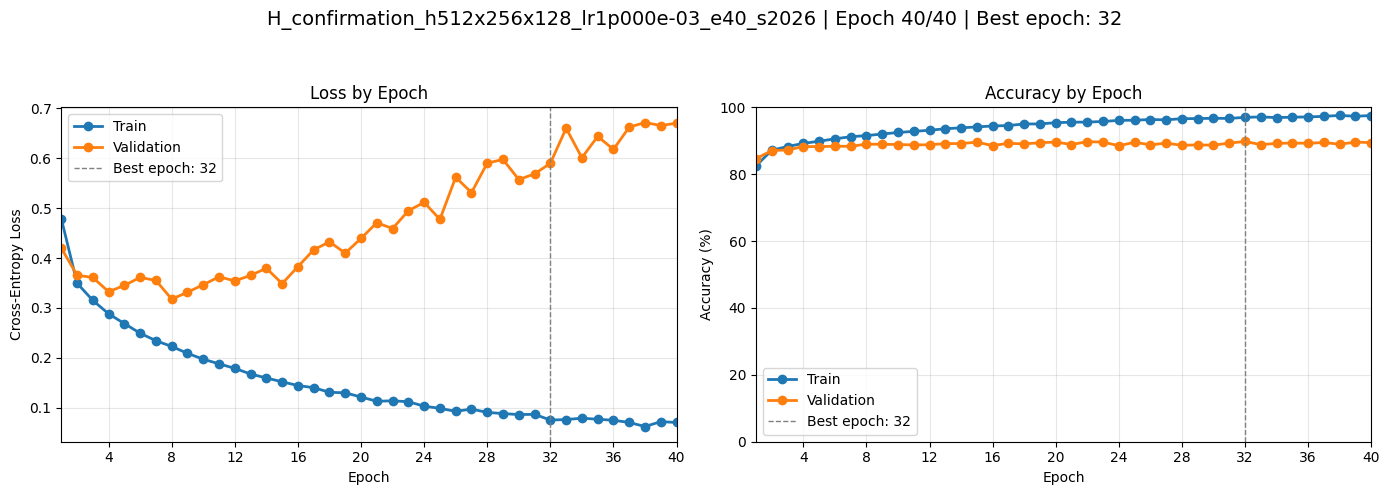

Epoch 01/40 | Train Loss 0.4792 | Train Accuracy 82.49% | Validation Loss 0.4202 | Validation Accuracy 84.62%


Epoch 02/40 | Train Loss 0.3497 | Train Accuracy 87.17% | Validation Loss 0.3656 | Validation Accuracy 87.08%


Epoch 03/40 | Train Loss 0.3152 | Train Accuracy 88.28% | Validation Loss 0.3611 | Validation Accuracy 87.25%


Epoch 04/40 | Train Loss 0.2883 | Train Accuracy 89.22% | Validation Loss 0.3325 | Validation Accuracy 88.28%


Epoch 05/40 | Train Loss 0.2687 | Train Accuracy 89.86% | Validation Loss 0.3452 | Validation Accuracy 88.25%


...

Epoch 37/40 | Train Loss 0.0705 | Train Accuracy 97.30% | Validation Loss 0.6625 | Validation Accuracy 89.48%


Epoch 38/40 | Train Loss 0.0623 | Train Accuracy 97.58% | Validation Loss 0.6718 | Validation Accuracy 88.97%


Epoch 39/40 | Train Loss 0.0721 | Train Accuracy 97.33% | Validation Loss 0.6657 | Validation Accuracy 89.60%


Epoch 40/40 | Train Loss 0.0704 | Train Accuracy 97.55% | Validation Loss 0.6706 | Validation Accuracy 89.45%


Running H_confirmation_h256x128_lr1p000e-03_e40_s42 | lr=0.001 | hidden=(256, 128)


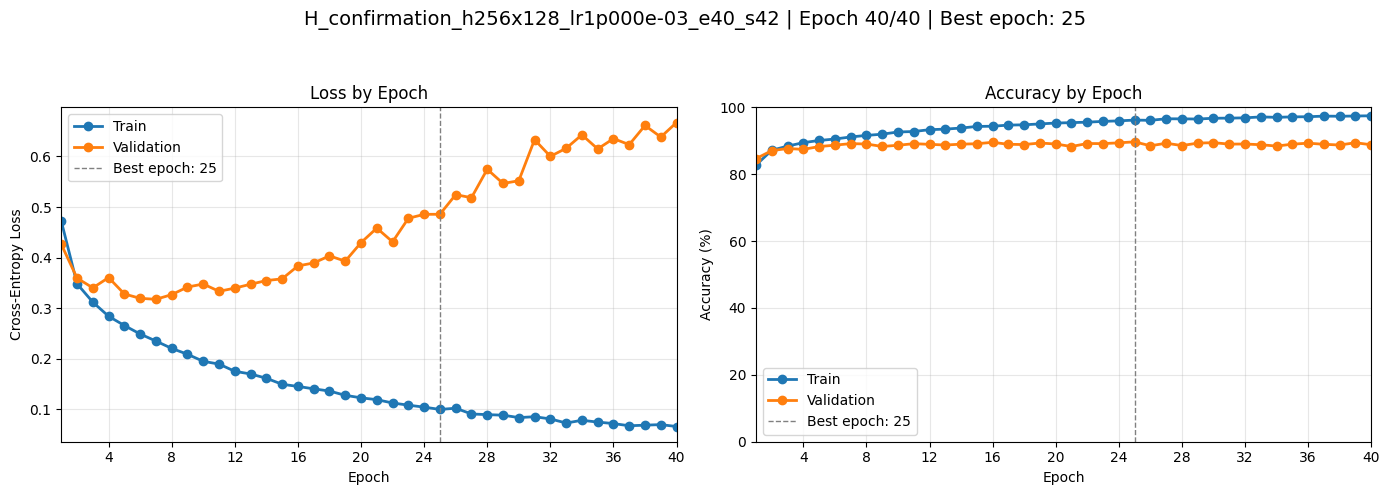

Epoch 01/40 | Train Loss 0.4722 | Train Accuracy 82.72% | Validation Loss 0.4263 | Validation Accuracy 84.65%


Epoch 02/40 | Train Loss 0.3482 | Train Accuracy 87.16% | Validation Loss 0.3595 | Validation Accuracy 87.05%


Epoch 03/40 | Train Loss 0.3120 | Train Accuracy 88.39% | Validation Loss 0.3403 | Validation Accuracy 87.68%


Epoch 04/40 | Train Loss 0.2841 | Train Accuracy 89.44% | Validation Loss 0.3606 | Validation Accuracy 87.43%


Epoch 05/40 | Train Loss 0.2658 | Train Accuracy 90.09% | Validation Loss 0.3282 | Validation Accuracy 88.27%


...

Epoch 37/40 | Train Loss 0.0677 | Train Accuracy 97.37% | Validation Loss 0.6233 | Validation Accuracy 88.95%


Epoch 38/40 | Train Loss 0.0689 | Train Accuracy 97.33% | Validation Loss 0.6611 | Validation Accuracy 88.73%


Epoch 39/40 | Train Loss 0.0700 | Train Accuracy 97.41% | Validation Loss 0.6383 | Validation Accuracy 89.42%


Epoch 40/40 | Train Loss 0.0662 | Train Accuracy 97.48% | Validation Loss 0.6670 | Validation Accuracy 88.80%


Running H_confirmation_h256x128_lr1p000e-03_e40_s123 | lr=0.001 | hidden=(256, 128)


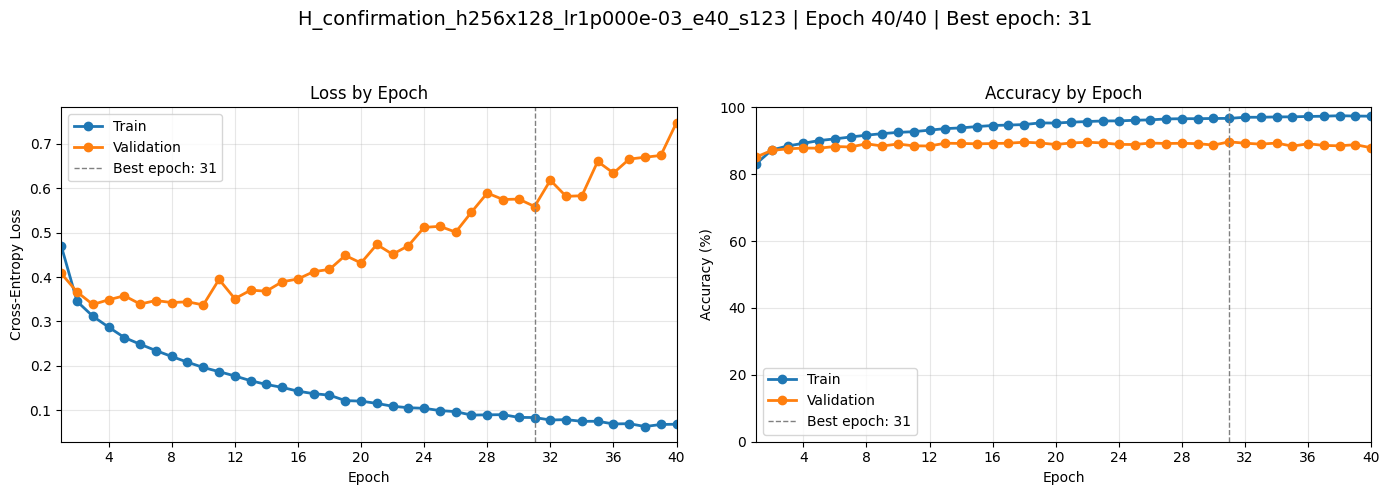

Epoch 01/40 | Train Loss 0.4697 | Train Accuracy 83.08% | Validation Loss 0.4080 | Validation Accuracy 85.12%


Epoch 02/40 | Train Loss 0.3452 | Train Accuracy 87.23% | Validation Loss 0.3664 | Validation Accuracy 87.12%


Epoch 03/40 | Train Loss 0.3118 | Train Accuracy 88.44% | Validation Loss 0.3382 | Validation Accuracy 87.58%


Epoch 04/40 | Train Loss 0.2873 | Train Accuracy 89.24% | Validation Loss 0.3488 | Validation Accuracy 87.82%


Epoch 05/40 | Train Loss 0.2638 | Train Accuracy 90.06% | Validation Loss 0.3578 | Validation Accuracy 87.78%


...

Epoch 37/40 | Train Loss 0.0701 | Train Accuracy 97.34% | Validation Loss 0.6654 | Validation Accuracy 88.60%


Epoch 38/40 | Train Loss 0.0636 | Train Accuracy 97.50% | Validation Loss 0.6696 | Validation Accuracy 88.50%


Epoch 39/40 | Train Loss 0.0682 | Train Accuracy 97.39% | Validation Loss 0.6735 | Validation Accuracy 88.83%


Epoch 40/40 | Train Loss 0.0688 | Train Accuracy 97.35% | Validation Loss 0.7476 | Validation Accuracy 87.90%


Running H_confirmation_h256x128_lr1p000e-03_e40_s2026 | lr=0.001 | hidden=(256, 128)


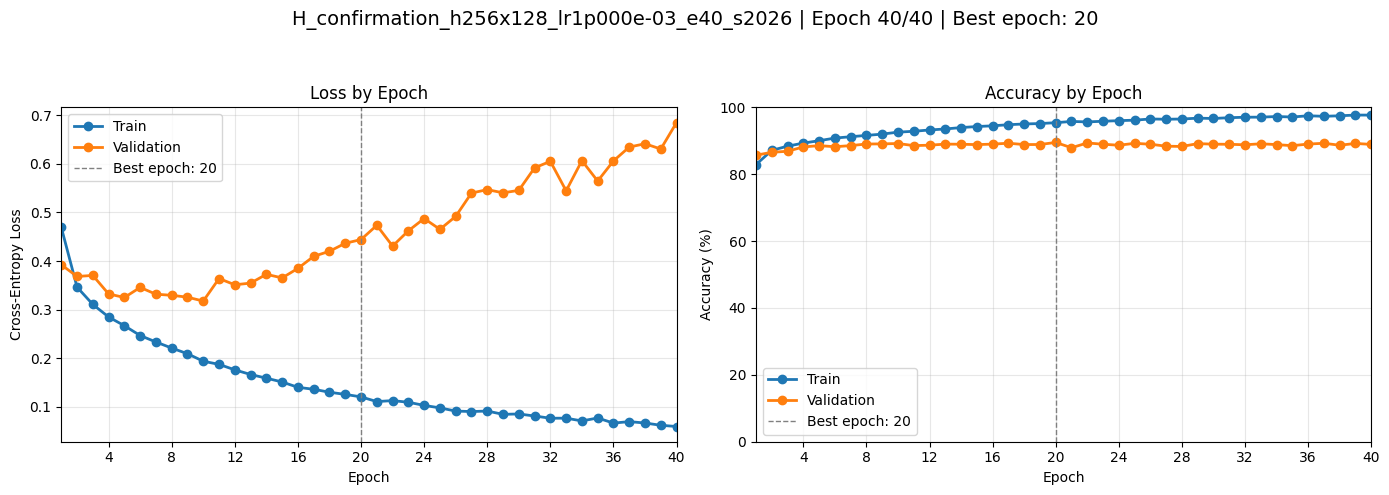

Epoch 01/40 | Train Loss 0.4695 | Train Accuracy 82.88% | Validation Loss 0.3925 | Validation Accuracy 85.68%


Epoch 02/40 | Train Loss 0.3464 | Train Accuracy 87.13% | Validation Loss 0.3684 | Validation Accuracy 86.55%


Epoch 03/40 | Train Loss 0.3108 | Train Accuracy 88.38% | Validation Loss 0.3705 | Validation Accuracy 86.87%


Epoch 04/40 | Train Loss 0.2850 | Train Accuracy 89.30% | Validation Loss 0.3324 | Validation Accuracy 88.15%


Epoch 05/40 | Train Loss 0.2671 | Train Accuracy 90.02% | Validation Loss 0.3251 | Validation Accuracy 88.55%


...

Epoch 37/40 | Train Loss 0.0698 | Train Accuracy 97.32% | Validation Loss 0.6346 | Validation Accuracy 89.25%


Epoch 38/40 | Train Loss 0.0669 | Train Accuracy 97.48% | Validation Loss 0.6414 | Validation Accuracy 88.67%


Epoch 39/40 | Train Loss 0.0623 | Train Accuracy 97.69% | Validation Loss 0.6305 | Validation Accuracy 89.20%


Epoch 40/40 | Train Loss 0.0597 | Train Accuracy 97.68% | Validation Loss 0.6850 | Validation Accuracy 88.92%


Stage D multi-seed confirmation ranking:
1. hidden=(512, 256, 128) | lr=0.001 | validation_accuracy=89.78% +/- 0.08% | validation_loss=0.5520 | median_best_epoch=32
2. hidden=(256, 128) | lr=0.001 | validation_accuracy=89.62% +/- 0.09% | validation_loss=0.4962 | median_best_epoch=25
Selected hyperparameters: h512x256x128_lr1p000e-03_do0p00_adam_aug0


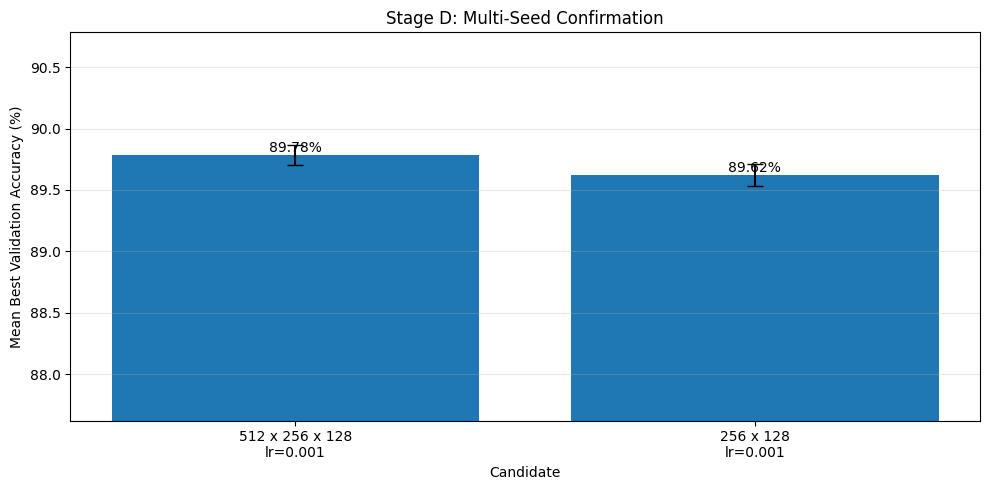

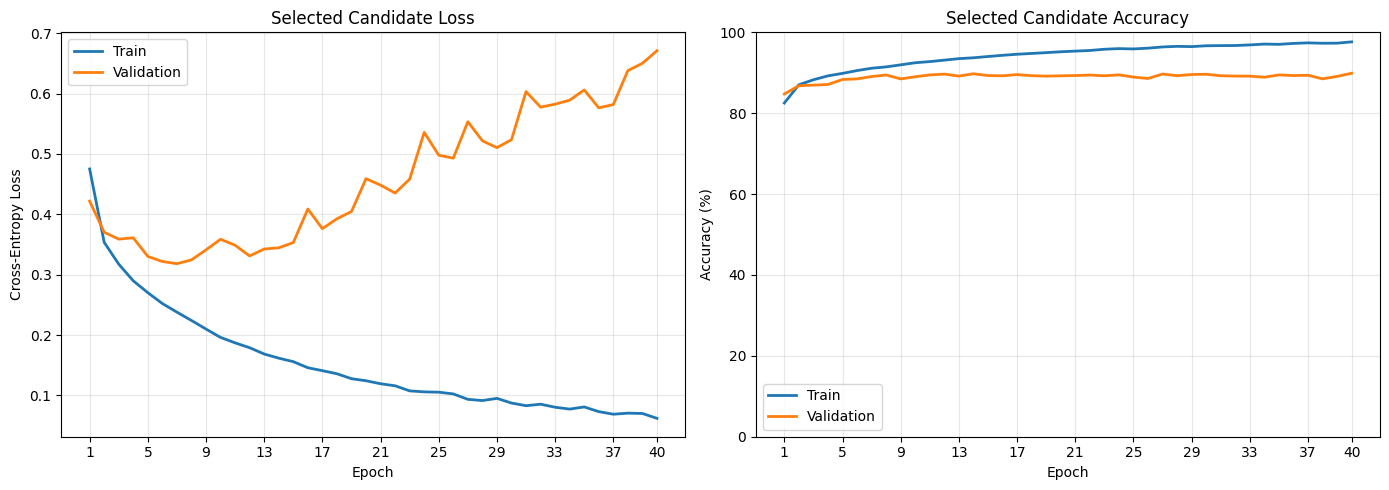

In [44]:
confirmation_candidate_configs = [
    result['config']
    for result in top_candidate_results
]
confirmation_trial_configs = generate_confirmation_trials(
    HYPERPARAMETER_BASE_CONFIG,
    confirmation_candidate_configs,
    seeds=CONFIRMATION_SEEDS,
    epochs=CONFIRMATION_EPOCHS,
)
confirmation_results = run_search_trials(
    confirmation_trial_configs
)
confirmation_summaries = aggregate_confirmation_results(
    confirmation_results
)
selected_hyperparameter_summary = confirmation_summaries[0]
selected_candidate_key = (
    selected_hyperparameter_summary['candidate_key']
)
selected_confirmation_results = [
    result
    for result in confirmation_results
    if result['config']['candidate_key'] == selected_candidate_key
]
selected_representative_result = rank_results(
    selected_confirmation_results
)[0]
selected_config = dict(selected_hyperparameter_summary['config'])
selected_config.update({
    'experiment_id': f'H_selected_{selected_candidate_key}',
    'hidden_dims': tuple(
        selected_hyperparameter_summary['hidden_dims']
    ),
    'learning_rate': (
        selected_hyperparameter_summary['learning_rate']
    ),
    'epochs': selected_hyperparameter_summary['median_best_epoch'],
    'seed': SEED,
    'search_stage': 'selected',
})
selected_result = dict(selected_representative_result)
selected_result.update({
    'experiment_id': selected_config['experiment_id'],
    'config': selected_config,
    'best_epoch': selected_hyperparameter_summary['median_best_epoch'],
    'best_validation_accuracy': (
        selected_hyperparameter_summary['mean_validation_accuracy']
    ),
    'best_validation_loss': (
        selected_hyperparameter_summary['mean_validation_loss']
    ),
})
model = selected_representative_result['model']
training_history = selected_representative_result['history']
all_search_results = (
    learning_rate_results
    + architecture_results
    + refinement_results
    + confirmation_results
)
export_search_outputs(
    all_search_results,
    confirmation_summaries,
    selected_hyperparameter_summary,
    HYPERPARAMETER_SEARCH_DIR,
)

print('Stage D multi-seed confirmation ranking:')
for rank, summary in enumerate(confirmation_summaries, start=1):
    print(
        f"{rank}. hidden={summary['hidden_dims']} | "
        f"lr={summary['learning_rate']:.6g} | "
        f"validation_accuracy="
        f"{summary['mean_validation_accuracy']:.2%} "
        f"+/- {summary['std_validation_accuracy']:.2%} | "
        f"validation_loss={summary['mean_validation_loss']:.4f} | "
        f"median_best_epoch={summary['median_best_epoch']}"
    )
print(f'Selected hyperparameters: {selected_candidate_key}')

confirmation_labels = [
    (
        ' x '.join(str(width) for width in summary['hidden_dims'])
        + f"\nlr={summary['learning_rate']:.3g}"
    )
    for summary in confirmation_summaries
]
confirmation_means = [
    summary['mean_validation_accuracy'] * 100
    for summary in confirmation_summaries
]
confirmation_errors = [
    summary['std_validation_accuracy'] * 100
    for summary in confirmation_summaries
]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    confirmation_labels,
    confirmation_means,
    yerr=confirmation_errors,
    capsize=6,
)
ax.set_title('Stage D: Multi-Seed Confirmation')
ax.set_xlabel('Candidate')
ax.set_ylabel('Mean Best Validation Accuracy (%)')
ax.set_ylim(
    max(0, min(confirmation_means) - 2),
    min(100, max(confirmation_means) + 1),
)
ax.grid(axis='y', alpha=0.3)
for bar, mean_score in zip(bars, confirmation_means):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        mean_score,
        f'{mean_score:.2f}%',
        ha='center',
        va='bottom',
    )
plt.tight_layout()
fig.savefig(
    SEARCH_PLOT_OUTPUT_DIR / 'confirmation_comparison.png',
    dpi=150,
    bbox_inches='tight',
)
plt.show()

selected_epochs = [
    record['epoch']
    for record in training_history
]
selected_tick_step = max(1, len(selected_epochs) // 10)
selected_ticks = selected_epochs[::selected_tick_step]
if selected_ticks[-1] != selected_epochs[-1]:
    selected_ticks.append(selected_epochs[-1])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(
    selected_epochs,
    [record['train_loss'] for record in training_history],
    label='Train',
    linewidth=2,
)
axes[0].plot(
    selected_epochs,
    [record['validation_loss'] for record in training_history],
    label='Validation',
    linewidth=2,
)
axes[0].set_title('Selected Candidate Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_xticks(selected_ticks)
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].plot(
    selected_epochs,
    [record['train_accuracy'] * 100 for record in training_history],
    label='Train',
    linewidth=2,
)
axes[1].plot(
    selected_epochs,
    [record['validation_accuracy'] * 100 for record in training_history],
    label='Validation',
    linewidth=2,
)
axes[1].set_title('Selected Candidate Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_xticks(selected_ticks)
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
fig.savefig(
    SEARCH_PLOT_OUTPUT_DIR / 'selected_candidate_history.png',
    dpi=150,
    bbox_inches='tight',
)
plt.show()

### Final Training

The selected hyperparameter configuration is rebuilt from fresh state and trained for its selected epoch count on all 60,000 official training images. This recovers the validation samples for parameter fitting after model selection is complete. The official test set remains untouched during this final training run.

In [45]:
def train_final_model(
    config: Dict,
    training_dataset,
    device: torch.device,
    log_directory: Optional[Path] = None,
    verbose: bool = True,
    monitor: Optional[TrainingMonitor] = None,
    checkpoint_manager: Optional[TrainingCheckpointManager] = None,
    resume_from_checkpoint: bool = True,
) -> Dict:
    set_reproducibility(config.get('seed', SEED))
    final_model = build_model(config).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(final_model, config)
    train_loader = make_train_loader(
        training_dataset,
        batch_size=config['batch_size'],
        seed=config.get('seed', SEED),
    )
    history = []
    active_log_directory = log_directory
    resumed_from_epoch = 0
    elapsed_before_resume = 0.0
    total_elapsed_seconds = 0.0
    recovery_state = (
        checkpoint_manager.load(map_location='cpu')
        if checkpoint_manager is not None and resume_from_checkpoint
        else None
    )

    if recovery_state is not None:
        if recovery_state['total_epochs'] != config['epochs']:
            raise RuntimeError(
                'Recovery checkpoint epoch budget does not match config'
            )
        final_model.load_state_dict(
            recovery_state['model_state_dict']
        )
        optimizer.load_state_dict(recovery_state['optimizer_state_dict'])
        history = list(recovery_state['history'])
        resumed_from_epoch = recovery_state['completed_epoch']
        elapsed_before_resume = recovery_state['elapsed_seconds']
        total_elapsed_seconds = elapsed_before_resume
        if recovery_state['log_directory']:
            active_log_directory = Path(
                recovery_state['log_directory']
            )
        restore_rng_state(
            recovery_state['rng_state'],
            train_loader.generator,
        )
        if verbose:
            print(
                f"Resuming {config['experiment_id']} after epoch "
                f"{resumed_from_epoch}/{config['epochs']}"
            )

    start_epoch = resumed_from_epoch + 1
    writer = (
        SummaryWriter(
            log_dir=str(active_log_directory),
            purge_step=(start_epoch if resumed_from_epoch else None),
        )
        if (
            active_log_directory is not None
            and start_epoch <= config['epochs']
        )
        else None
    )
    if monitor is not None and history:
        monitor.restore(history)
    started_at = time.perf_counter()

    try:
        for epoch in range(start_epoch, config['epochs'] + 1):
            train_metrics = train_one_epoch(
                final_model,
                train_loader,
                criterion,
                optimizer,
                device,
            )
            epoch_record = {
                'epoch': epoch,
                'train_loss': train_metrics['loss'],
                'train_accuracy': train_metrics['accuracy'],
                'learning_rate': optimizer.param_groups[0]['lr'],
                'elapsed_seconds': train_metrics['elapsed_seconds'],
            }
            history.append(epoch_record)

            if writer is not None:
                writer.add_scalar(
                    'Loss/Train',
                    train_metrics['loss'],
                    epoch,
                )
                writer.add_scalar(
                    'Accuracy/Train',
                    train_metrics['accuracy'],
                    epoch,
                )
                writer.add_scalar(
                    'LearningRate',
                    optimizer.param_groups[0]['lr'],
                    epoch,
                )
                writer.flush()

            total_elapsed_seconds = (
                elapsed_before_resume
                + time.perf_counter() - started_at
            )
            if checkpoint_manager is not None:
                checkpoint_manager.save({
                    'status': (
                        'completed'
                        if epoch == config['epochs']
                        else 'in_progress'
                    ),
                    'completed_epoch': epoch,
                    'total_epochs': config['epochs'],
                    'model_state_dict': final_model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'history': history,
                    'best_state_dict': None,
                    'best_epoch': 0,
                    'best_validation_accuracy': None,
                    'best_validation_loss': None,
                    'rng_state': capture_rng_state(
                        train_loader.generator
                    ),
                    'elapsed_seconds': total_elapsed_seconds,
                    'log_directory': (
                        str(active_log_directory)
                        if active_log_directory is not None
                        else ''
                    ),
                })

            if monitor is not None:
                monitor.update(epoch_record)

            if verbose:
                print(
                    f"Final Epoch {epoch:02d}/{config['epochs']} | "
                    f"Train Loss {train_metrics['loss']:.4f} | "
                    f"Train Accuracy {train_metrics['accuracy']:.2%}"
                )
    finally:
        if writer is not None:
            writer.close()

    final_model.eval()
    return {
        'model': final_model,
        'history': history,
        'config': dict(config),
        'parameter_count': count_trainable_parameters(final_model),
        'training_sample_count': len(training_dataset),
        'total_seconds': (
            total_elapsed_seconds
            if history
            else time.perf_counter() - started_at
        ),
        'resumed_from_epoch': resumed_from_epoch,
        'recovery_checkpoint_path': (
            str(checkpoint_manager.path)
            if checkpoint_manager is not None
            else None
        ),
    }

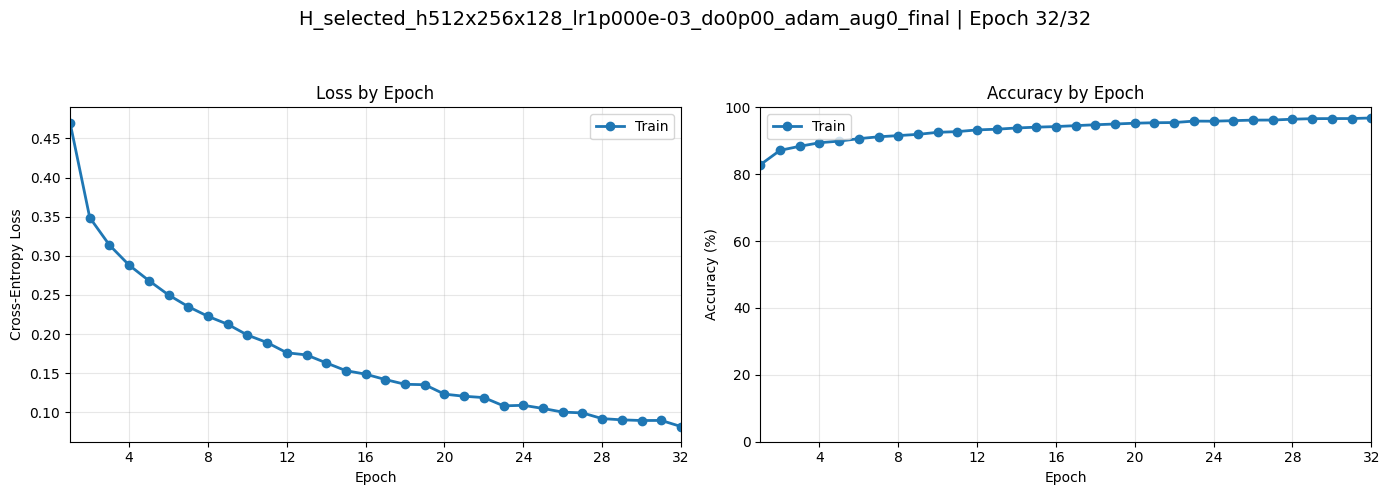

Final Epoch 01/32 | Train Loss 0.4703 | Train Accuracy 82.83%


Final Epoch 02/32 | Train Loss 0.3489 | Train Accuracy 87.14%


Final Epoch 03/32 | Train Loss 0.3137 | Train Accuracy 88.35%


Final Epoch 04/32 | Train Loss 0.2881 | Train Accuracy 89.41%


Final Epoch 05/32 | Train Loss 0.2683 | Train Accuracy 89.89%


...

Final Epoch 29/32 | Train Loss 0.0904 | Train Accuracy 96.61%


Final Epoch 30/32 | Train Loss 0.0896 | Train Accuracy 96.64%


Final Epoch 31/32 | Train Loss 0.0897 | Train Accuracy 96.65%


Final Epoch 32/32 | Train Loss 0.0819 | Train Accuracy 96.82%


Final training samples: 60,000
Final training epochs: 32


In [46]:
final_config = dict(selected_config)
final_config['experiment_id'] = (
    f"{selected_config['experiment_id']}_final"
)
final_config['epochs'] = selected_result['best_epoch']
final_training_dataset = (
    augmented_training_pool
    if final_config['use_augmentation']
    else baseline_training_pool
)

final_signature = build_checkpoint_signature({
    'contract': 'fashion-mnist-practice-1-final-v1',
    'config': final_config,
    'training_sample_count': len(final_training_dataset),
    'dataset': 'FashionMNIST-official-training-partition',
    'train_mean': TRAIN_MEAN,
    'train_std': TRAIN_STD,
    'device_type': device.type,
    'torch_version': torch.__version__,
    'torchvision_version': torchvision.__version__,
})
final_checkpoint_manager = TrainingCheckpointManager(
    RECOVERY_OUTPUT_DIR
    / f"{final_config['experiment_id']}.resume.pth",
    run_kind='final',
    run_id=final_config['experiment_id'],
    signature=final_signature,
    enabled=ENABLE_RECOVERY_CHECKPOINTS,
)

final_monitor = TrainingMonitor(
    run_name=final_config['experiment_id'],
    total_epochs=final_config['epochs'],
    include_validation=False,
    enabled=ENABLE_LIVE_TRAINING_PLOTS,
    save_path=(
        SEARCH_PLOT_OUTPUT_DIR
        / f"{final_config['experiment_id']}.png"
    ),
)
with final_monitor:
    final_training_result = train_final_model(
        final_config,
        final_training_dataset,
        device,
        log_directory=RUN_ROOT / final_config['experiment_id'],
        monitor=final_monitor,
        checkpoint_manager=final_checkpoint_manager,
        resume_from_checkpoint=RESUME_IF_AVAILABLE,
    )
model = final_training_result['model']
final_training_history = final_training_result['history']

assert final_training_result['training_sample_count'] == len(
    final_training_dataset
)
print(
    f"Final training samples: "
    f"{final_training_result['training_sample_count']:,}"
)
print(f"Final training epochs: {final_config['epochs']}")

In [47]:
TENSORBOARD_LOG_DIR = str(RUNS_DIR)
%load_ext tensorboard
%tensorboard --logdir $TENSORBOARD_LOG_DIR

Reusing TensorBoard on port 6006 (pid 64624), started 3:05:14 ago. (Use '!kill 64624' to kill it.)

## Phase 8 - Model Evaluation

After preprocessing, experiments, model selection and final training are complete, the final model is evaluated on the untouched 10,000-image official test set. This phase computes sample-weighted cross-entropy loss, overall accuracy, per-class precision/recall/F1, one-vs-rest TN/TP/FN/FP/TPR/FPR metrics and a confusion matrix. No result from this phase changes the selected configuration or training process.

In [48]:
def evaluate_classifier(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> Dict:
    model.eval()
    loss_sum = 0.0
    correct = 0
    sample_count = 0
    prediction_batches = []
    target_batches = []
    probability_batches = []

    with torch.inference_mode():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            if not torch.isfinite(loss):
                raise FloatingPointError('Non-finite test loss')

            probabilities = torch.softmax(logits, dim=1)
            predictions = logits.argmax(dim=1)
            batch_size = labels.size(0)
            loss_sum += loss.item() * batch_size
            correct += predictions.eq(labels).sum().item()
            sample_count += batch_size
            prediction_batches.append(predictions.cpu())
            target_batches.append(labels.cpu())
            probability_batches.append(probabilities.cpu())

    if sample_count == 0:
        raise ValueError('Test loader is empty')

    prediction_tensor = torch.cat(prediction_batches)
    target_tensor = torch.cat(target_batches)
    probability_tensor = torch.cat(probability_batches)

    if prediction_tensor.shape != (sample_count,):
        raise ValueError('Prediction count does not match sample count')
    if target_tensor.shape != (sample_count,):
        raise ValueError('Target count does not match sample count')
    if probability_tensor.ndim != 2:
        raise ValueError('Probabilities must be a two-dimensional tensor')
    if probability_tensor.shape[0] != sample_count:
        raise ValueError('Probability count does not match sample count')
    if probability_tensor.shape[1] < 2:
        raise ValueError('Classifier must produce at least two classes')
    if not torch.isfinite(probability_tensor).all():
        raise FloatingPointError('Non-finite test probabilities')
    if (probability_tensor < 0).any() or (probability_tensor > 1).any():
        raise ValueError('Test probabilities must be in the [0, 1] range')

    probability_sums = probability_tensor.sum(dim=1)
    if not torch.allclose(
        probability_sums,
        torch.ones_like(probability_sums),
        rtol=1e-5,
        atol=1e-6,
    ):
        raise ValueError('Probabilities must sum to one for every sample')
    if not torch.equal(probability_tensor.argmax(dim=1), prediction_tensor):
        raise ValueError('Probability argmax does not match predictions')

    return {
        'loss': loss_sum / sample_count,
        'accuracy': correct / sample_count,
        'sample_count': sample_count,
        'predictions': prediction_tensor.numpy(),
        'targets': target_tensor.numpy(),
        'probabilities': probability_tensor.numpy(),
    }

In [49]:
test_criterion = nn.CrossEntropyLoss()
test_result = evaluate_classifier(
    model,
    test_loader,
    test_criterion,
    device,
)

assert test_result['sample_count'] == len(test_loader.dataset)
assert test_result['probabilities'].shape == (
    test_result['sample_count'],
    len(class_names),
)
print(f"Test samples: {test_result['sample_count']:,}")
print(f"Test loss: {test_result['loss']:.4f}")
print(f"Test accuracy: {test_result['accuracy']:.2%}")

Test samples: 10,000
Test loss: 0.5489
Test accuracy: 89.42%


In [50]:
classification_summary = classification_report(
    test_result['targets'],
    test_result['predictions'],
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

if not isinstance(classification_summary, dict):
    raise TypeError('Expected classification_report to return a dictionary')

confusion = confusion_matrix(
    test_result['targets'],
    test_result['predictions'],
)
total_samples = int(confusion.sum())
per_class_evaluation = []

assert confusion.shape == (len(class_names), len(class_names))
assert total_samples == test_result['sample_count']

for class_index, class_name in enumerate(class_names):
    true_positive = int(confusion[class_index, class_index])
    false_negative = int(confusion[class_index, :].sum() - true_positive)
    false_positive = int(confusion[:, class_index].sum() - true_positive)
    true_negative = int(
        total_samples - true_positive - false_negative - false_positive
    )
    positive_count = true_positive + false_negative
    negative_count = true_negative + false_positive
    true_positive_rate = (
        true_positive / positive_count if positive_count else 0.0
    )
    false_positive_rate = (
        false_positive / negative_count if negative_count else 0.0
    )
    class_metrics = classification_summary[class_name]

    if not isinstance(class_metrics, dict):
        raise TypeError(f'Expected metrics dictionary for {class_name}')

    assert positive_count == int(class_metrics['support'])
    assert (
        true_negative + true_positive + false_negative + false_positive
        == total_samples
    )
    assert np.isclose(true_positive_rate, class_metrics['recall'])

    per_class_evaluation.append({
        'class_name': class_name,
        'precision': class_metrics['precision'],
        'recall': class_metrics['recall'],
        'f1_score': class_metrics['f1-score'],
        'support': int(class_metrics['support']),
        'tn': true_negative,
        'tp': true_positive,
        'fn': false_negative,
        'fp': false_positive,
        'tpr': true_positive_rate,
        'fpr': false_positive_rate,
    })

assert sum(row['tp'] for row in per_class_evaluation) == round(
    test_result['accuracy'] * total_samples
)
assert sum(row['fn'] for row in per_class_evaluation) == sum(
    row['fp'] for row in per_class_evaluation
)

header = (
    f"{'class':12s} {'precision':>9s} {'recall':>8s} {'f1-score':>9s} "
    f"{'support':>7s} {'tn':>5s} {'tp':>5s} {'fn':>5s} {'fp':>5s} "
    f"{'tpr':>8s} {'fpr':>8s}"
)
print(header)

for row in per_class_evaluation:
    print(
        f"{row['class_name']:12s} "
        f"{row['precision']:9.4f} "
        f"{row['recall']:8.4f} "
        f"{row['f1_score']:9.4f} "
        f"{row['support']:7d} "
        f"{row['tn']:5d} "
        f"{row['tp']:5d} "
        f"{row['fn']:5d} "
        f"{row['fp']:5d} "
        f"{row['tpr']:8.4f} "
        f"{row['fpr']:8.4f}"
    )

for aggregate_name in ('macro avg', 'weighted avg'):
    aggregate = classification_summary[aggregate_name]
    if not isinstance(aggregate, dict):
        raise TypeError(f'Expected metrics dictionary for {aggregate_name}')
    print(
        f"{aggregate_name:12s} "
        f"{aggregate['precision']:9.4f} "
        f"{aggregate['recall']:8.4f} "
        f"{aggregate['f1-score']:9.4f} "
        f"{int(aggregate['support']):7d}"
    )

overall_accuracy = float(classification_summary['accuracy'])
print(f"{'accuracy':12s} {overall_accuracy:9.4f}")

class        precision   recall  f1-score support    tn    tp    fn    fp      tpr      fpr
T-shirt/top     0.8092   0.8820    0.8440    1000  8792   882   118   208   0.8820   0.0231
Trouser         0.9949   0.9750    0.9848    1000  8995   975    25     5   0.9750   0.0006
Pullover        0.8465   0.8050    0.8252    1000  8854   805   195   146   0.8050   0.0162
Dress           0.8941   0.9030    0.8985    1000  8893   903    97   107   0.9030   0.0119
Coat            0.8061   0.8480    0.8265    1000  8796   848   152   204   0.8480   0.0227
Sandal          0.9875   0.9460    0.9663    1000  8988   946    54    12   0.9460   0.0013
Shirt           0.7476   0.6930    0.7193    1000  8766   693   307   234   0.6930   0.0260
Sneaker         0.9445   0.9530    0.9487    1000  8944   953    47    56   0.9530   0.0062
Bag             0.9737   0.9640    0.9688    1000  8974   964    36    26   0.9640   0.0029
Ankle boot      0.9419   0.9730    0.9572    1000  8940   973    27    60   0.97

### Result Analysis

The model achieved an **accuracy of 89.42%** on a test set of 10,000 images that were completely unseen during any previous stages (test loss: 0.5489). Looking at the classification report, there is a distinct performance gap among the classes:

- **Best-performing group**: Trouser (F1 = 0.9848), Bag (F1 = 0.9688), and Sandal (F1 = 0.9663), all scoring above 96%. These items possess unique, distinct geometric shapes that make them difficult to confuse with other categories.

- **Weakest group**: Shirt (F1 = 0.7193), Pullover (F1 = 0.8252), and Coat (F1 = 0.8265) represent the three lowest F1-scores across all 10 classes.

**Shirt** stands out as the primary weakness, suffering from both low precision (0.7476) and low recall (0.6930). This indicates that not only are many actual Shirt images misclassified (false negatives and low TPR), but images from other classes are also frequently mispredicted as Shirt (false positives).

For every class, TP, FN, FP and TN are computed with a one-vs-rest view. TPR equals recall and measures how many ground-truth samples of the class are detected. FPR measures how many samples from the other nine classes are incorrectly predicted as the class. Each row is validated so that TN + TP + FN + FP equals all 10,000 test samples.

According to the confusion matrix, most errors for Shirt stem from three main confusions: being misclassified as **T-shirt/top**, **Pullover**, or **Coat**. This aligns with expectations, as all four classes represent upper-body garments. At a low resolution of $28 \times 28$ grayscale pixels, fine distinguishing details such as collar style, sleeve length, or fabric texture are almost completely lost.

Similarly, **Coat** suffers from significant overlap with **Pullover** and **Shirt** for the same reason. This quartet of upper-body garments (Shirt, Pullover, Coat, and T-shirt/top) is widely acknowledged across benchmark literature as the most challenging cluster in the FashionMNIST dataset.

**Conclusion:** The model effectively learns objects with distinct silhouettes (Trouser, Bag, Sandal, Ankle boot). It struggles with upper-body clothing, where low-resolution visual overlap and the spatial limitations of the MLP baseline may both contribute. The current confusion counts identify the error pattern, but a controlled CNN comparison is required before assigning the cause to the dataset alone.

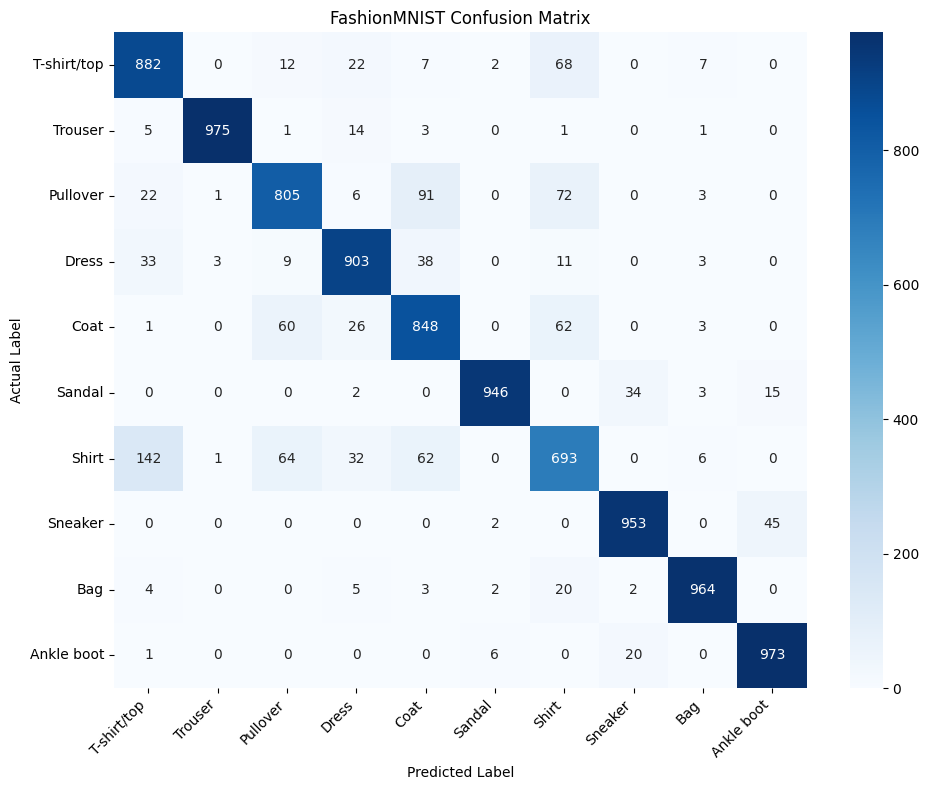

In [51]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title('FashionMNIST Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [52]:
number_of_classes = len(class_names)
curve_targets = np.asarray(test_result['targets'], dtype=np.int64)
curve_probabilities = np.asarray(
    test_result['probabilities'],
    dtype=np.float64,
)
curve_predictions = np.asarray(
    test_result['predictions'],
    dtype=np.int64,
)
expected_probability_shape = (
    test_result['sample_count'],
    number_of_classes,
)

if curve_targets.shape != (test_result['sample_count'],):
    raise ValueError('Curve targets do not match the test sample count')
if curve_predictions.shape != curve_targets.shape:
    raise ValueError('Curve predictions do not match the target shape')
if curve_probabilities.shape != expected_probability_shape:
    raise ValueError('Curve probabilities have an unexpected shape')
if not np.isfinite(curve_probabilities).all():
    raise FloatingPointError('Curve probabilities contain non-finite values')
if curve_targets.min() < 0 or curve_targets.max() >= number_of_classes:
    raise ValueError('Curve targets contain an unknown class index')
if not np.allclose(
    curve_probabilities.sum(axis=1),
    1.0,
    rtol=1e-5,
    atol=1e-6,
):
    raise ValueError('Curve probabilities must sum to one per sample')
if not np.array_equal(
    curve_probabilities.argmax(axis=1),
    curve_predictions,
):
    raise ValueError('Curve probability argmax does not match predictions')

one_vs_rest_targets = np.eye(
    number_of_classes,
    dtype=np.uint8,
)[curve_targets]
class_positive_counts = one_vs_rest_targets.sum(axis=0)
class_negative_counts = (
    test_result['sample_count'] - class_positive_counts
)
class_prevalence = one_vs_rest_targets.mean(axis=0)

if (class_positive_counts == 0).any():
    raise ValueError('Every class needs at least one positive test sample')
if (class_negative_counts == 0).any():
    raise ValueError('Every class needs at least one negative test sample')

assert one_vs_rest_targets.shape == expected_probability_shape
assert np.all(one_vs_rest_targets.sum(axis=1) == 1)

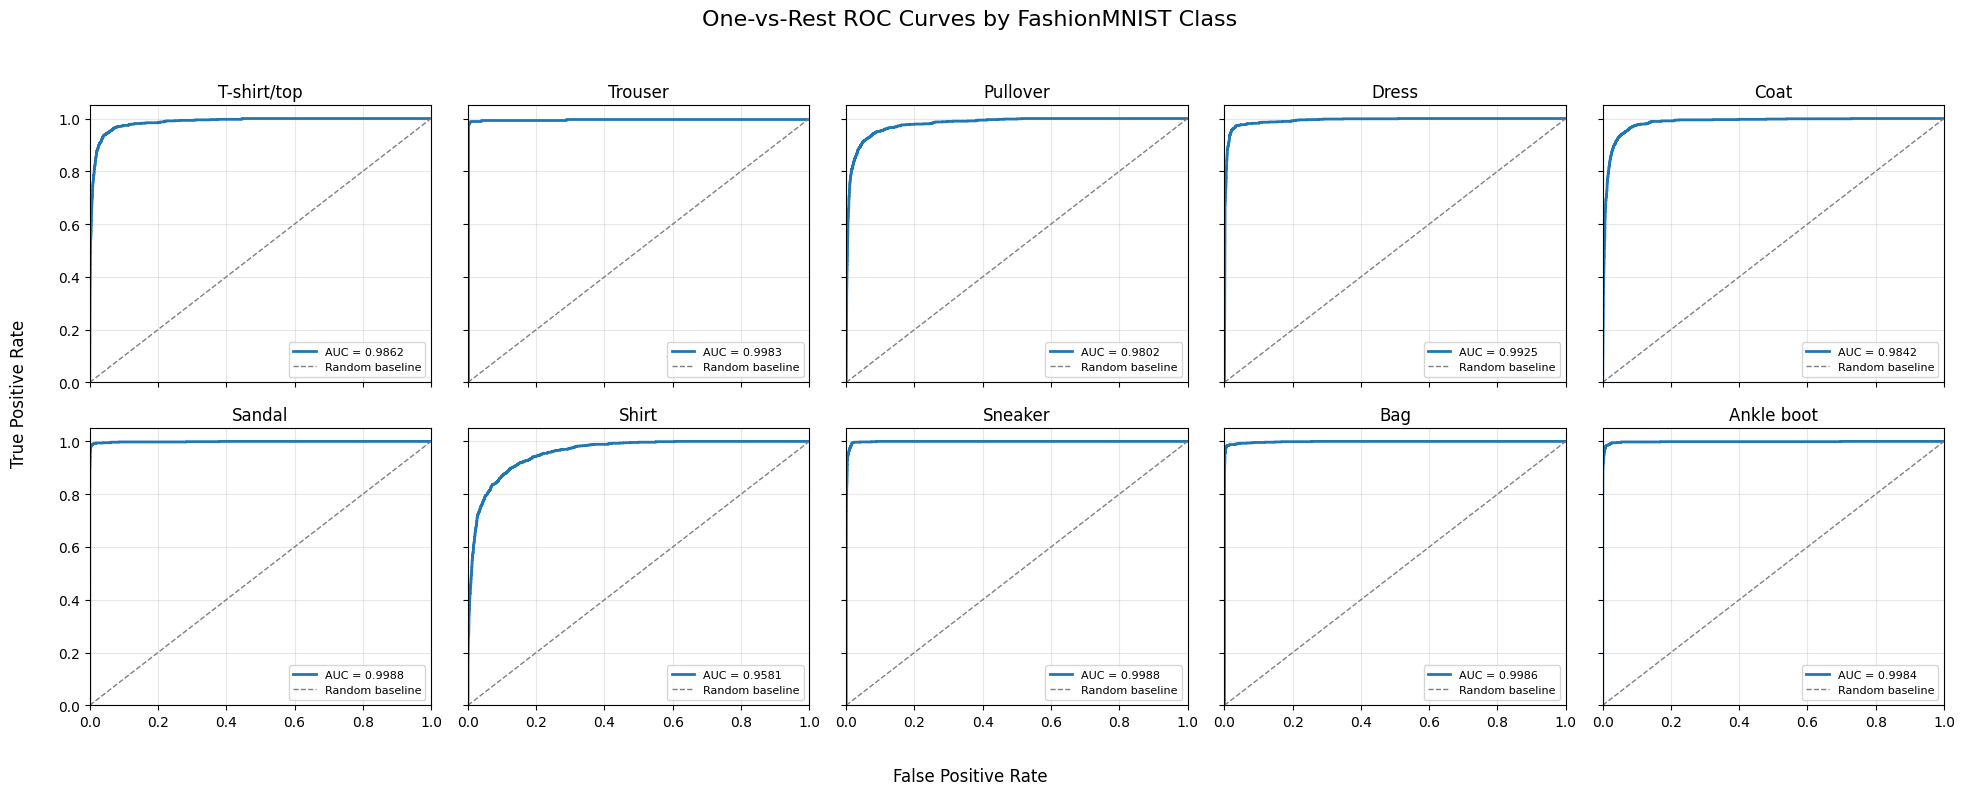

In [53]:
roc_curve_results = {}
subplot_columns = min(5, number_of_classes)
subplot_rows = int(np.ceil(number_of_classes / subplot_columns))
fig, axes = plt.subplots(
    subplot_rows,
    subplot_columns,
    figsize=(4 * subplot_columns, 4 * subplot_rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)
flat_axes = axes.flatten()

for class_index, class_name in enumerate(class_names):
    class_fpr, class_tpr, _ = roc_curve(
        one_vs_rest_targets[:, class_index],
        curve_probabilities[:, class_index],
    )
    class_roc_auc = float(auc(class_fpr, class_tpr))

    if not np.isfinite(class_fpr).all():
        raise FloatingPointError(f'Non-finite ROC FPR for {class_name}')
    if not np.isfinite(class_tpr).all():
        raise FloatingPointError(f'Non-finite ROC TPR for {class_name}')
    if not 0.0 <= class_roc_auc <= 1.0:
        raise ValueError(f'ROC AUC is outside [0, 1] for {class_name}')
    if not (
        np.isclose(class_fpr[0], 0.0)
        and np.isclose(class_tpr[0], 0.0)
        and np.isclose(class_fpr[-1], 1.0)
        and np.isclose(class_tpr[-1], 1.0)
    ):
        raise ValueError(f'ROC endpoints are invalid for {class_name}')

    roc_curve_results[class_name] = {
        'fpr': class_fpr,
        'tpr': class_tpr,
        'auc': class_roc_auc,
    }

    axis = flat_axes[class_index]
    axis.plot(
        class_fpr,
        class_tpr,
        linewidth=2,
        label=f'AUC = {class_roc_auc:.4f}',
    )
    axis.plot(
        [0, 1],
        [0, 1],
        linestyle='--',
        color='gray',
        linewidth=1,
        label='Random baseline',
    )
    axis.set_title(class_name)
    axis.set_xlim(0.0, 1.0)
    axis.set_ylim(0.0, 1.05)
    axis.grid(True, alpha=0.3)
    axis.legend(loc='lower right', fontsize=8)

for axis in flat_axes[number_of_classes:]:
    axis.set_visible(False)

fig.suptitle('One-vs-Rest ROC Curves by FashionMNIST Class', fontsize=16)
fig.supxlabel('False Positive Rate')
fig.supylabel('True Positive Rate')
plt.tight_layout(rect=(0.02, 0.02, 1.0, 0.95))
plt.show()

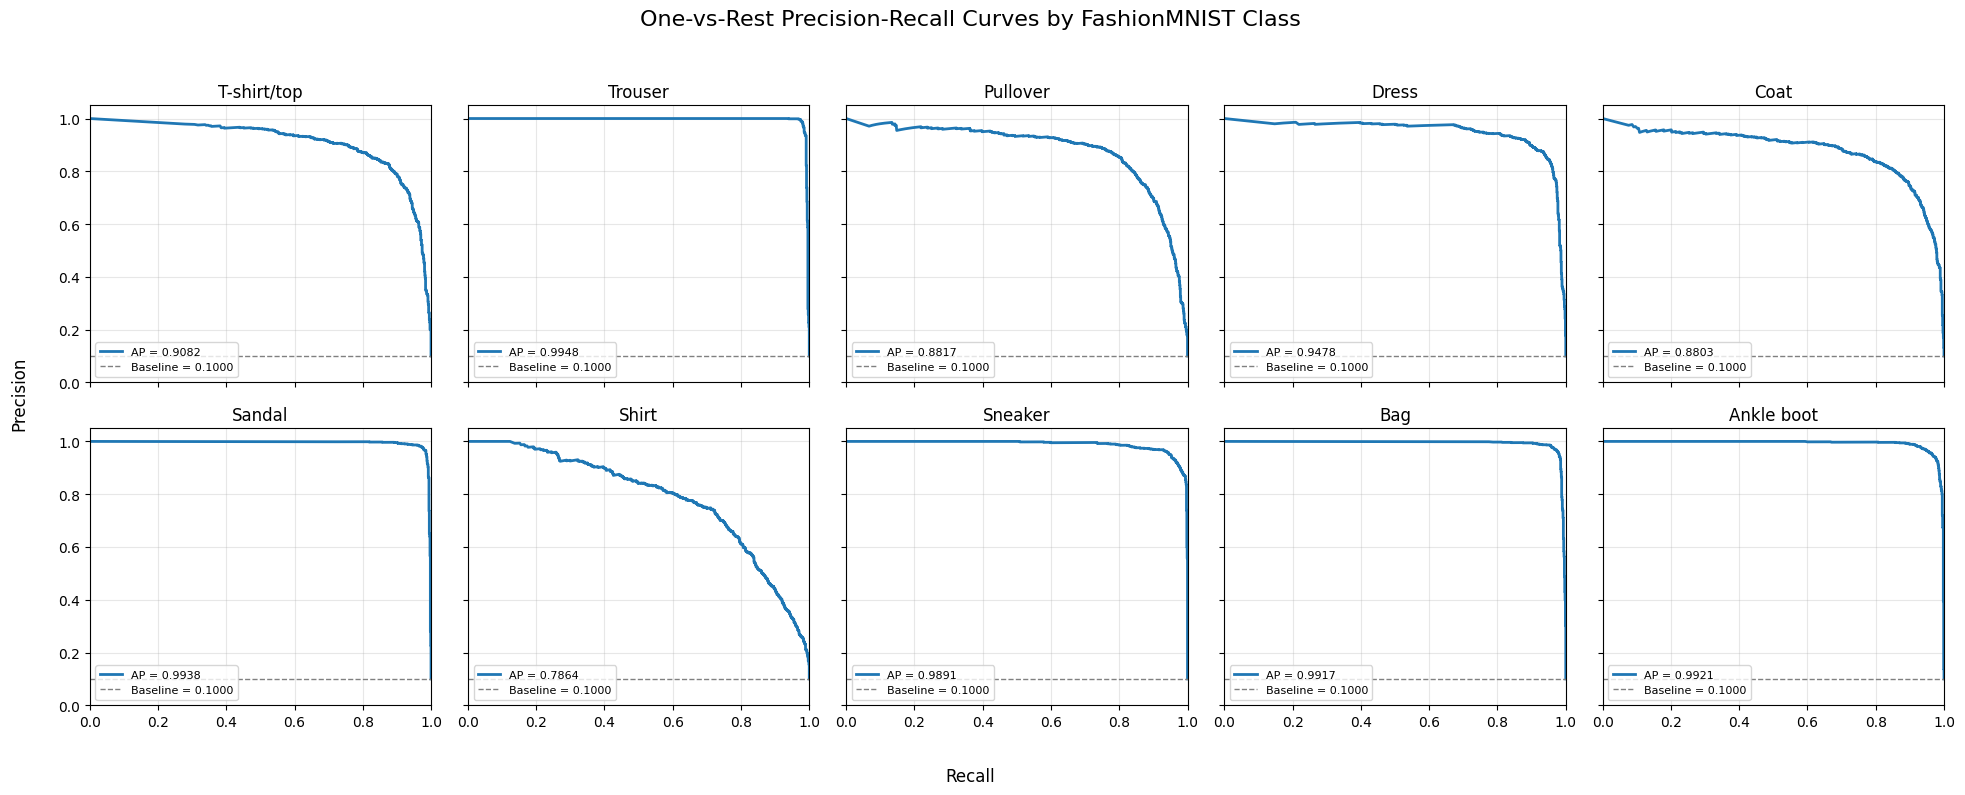

In [54]:
precision_recall_results = {}
fig, axes = plt.subplots(
    subplot_rows,
    subplot_columns,
    figsize=(4 * subplot_columns, 4 * subplot_rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)
flat_axes = axes.flatten()

for class_index, class_name in enumerate(class_names):
    class_precision, class_recall, _ = precision_recall_curve(
        one_vs_rest_targets[:, class_index],
        curve_probabilities[:, class_index],
    )
    class_average_precision = float(average_precision_score(
        one_vs_rest_targets[:, class_index],
        curve_probabilities[:, class_index],
    ))
    prevalence = float(class_prevalence[class_index])

    if not np.isfinite(class_precision).all():
        raise FloatingPointError(f'Non-finite PR precision for {class_name}')
    if not np.isfinite(class_recall).all():
        raise FloatingPointError(f'Non-finite PR recall for {class_name}')
    if not 0.0 <= class_average_precision <= 1.0:
        raise ValueError(f'Average precision is outside [0, 1] for {class_name}')
    if not (
        np.isclose(class_recall[0], 1.0)
        and np.isclose(class_recall[-1], 0.0)
        and np.isclose(class_precision[-1], 1.0)
    ):
        raise ValueError(f'Precision-recall endpoints are invalid for {class_name}')

    precision_recall_results[class_name] = {
        'precision': class_precision,
        'recall': class_recall,
        'average_precision': class_average_precision,
        'prevalence': prevalence,
    }

    axis = flat_axes[class_index]
    axis.plot(
        class_recall,
        class_precision,
        linewidth=2,
        label=f'AP = {class_average_precision:.4f}',
    )
    axis.axhline(
        prevalence,
        linestyle='--',
        color='gray',
        linewidth=1,
        label=f'Baseline = {prevalence:.4f}',
    )
    axis.set_title(class_name)
    axis.set_xlim(0.0, 1.0)
    axis.set_ylim(0.0, 1.05)
    axis.grid(True, alpha=0.3)
    axis.legend(loc='lower left', fontsize=8)

for axis in flat_axes[number_of_classes:]:
    axis.set_visible(False)

fig.suptitle(
    'One-vs-Rest Precision-Recall Curves by FashionMNIST Class',
    fontsize=16,
)
fig.supxlabel('Recall')
fig.supylabel('Precision')
plt.tight_layout(rect=(0.02, 0.02, 1.0, 0.95))
plt.show()

## Phase 9 - Save Model & Visualization

The final checkpoint stores model weights together with the architecture, preprocessing statistics, selected validation result and final training metadata. A fresh model is reconstructed from the saved configuration, loaded on the selected device and checked against the in-memory model before prediction examples are displayed.

In [55]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = OUTPUT_DIR / 'fashion_mnist_model.pth'

checkpoint = {
    'model_state_dict': clone_to_cpu(model.state_dict()),
    'model_config': {
        'hidden_dims': tuple(final_config['hidden_dims']),
        'dropout': final_config['dropout'],
        'num_classes': final_config['num_classes'],
        'input_dim': final_config['input_dim'],
    },
    'training_config': dict(final_config),
    'selected_experiment': selected_result['experiment_id'],
    'best_epoch': selected_result['best_epoch'],
    'best_validation_accuracy': (
        selected_result['best_validation_accuracy']
    ),
    'best_validation_loss': selected_result['best_validation_loss'],
    'test_accuracy': test_result['accuracy'],
    'test_loss': test_result['loss'],
    'train_mean': TRAIN_MEAN,
    'train_std': TRAIN_STD,
    'class_names': list(class_names),
    'final_training_history': final_training_history,
    'final_training_total_seconds': (
        final_training_result['total_seconds']
    ),
    'final_training_resumed_from_epoch': (
        final_training_result['resumed_from_epoch']
    ),
    'recovery_checkpoint_path': (
        final_training_result['recovery_checkpoint_path']
    ),
}

atomic_torch_save(checkpoint, MODEL_PATH)
print(f'Model saved to: {MODEL_PATH}')

Model saved to: /Users/voanhnhat-ticoder-coder/Documents/DEEP_LEARNING/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_1/outputs/fashion_mnist_model.pth


In [56]:
loaded_checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=True,
)
loaded_model = FashionMNISTModel(
    **loaded_checkpoint['model_config'],
).to(device)
loaded_model.load_state_dict(
    loaded_checkpoint['model_state_dict'],
)
loaded_model.eval()

verification_images, verification_labels = next(iter(test_loader))
verification_images_device = verification_images.to(device)

with torch.inference_mode():
    original_logits = model(verification_images_device)
    loaded_logits = loaded_model(verification_images_device)

maximum_logit_difference = (
    original_logits - loaded_logits
).abs().max().item()
predictions_match = torch.equal(
    original_logits.argmax(dim=1),
    loaded_logits.argmax(dim=1),
)

assert predictions_match
assert torch.allclose(original_logits, loaded_logits)

print(f'Predictions match: {predictions_match}')
print(
    f'Maximum logit difference: '
    f'{maximum_logit_difference:.8f}'
)

Predictions match: True
Maximum logit difference: 0.00000000


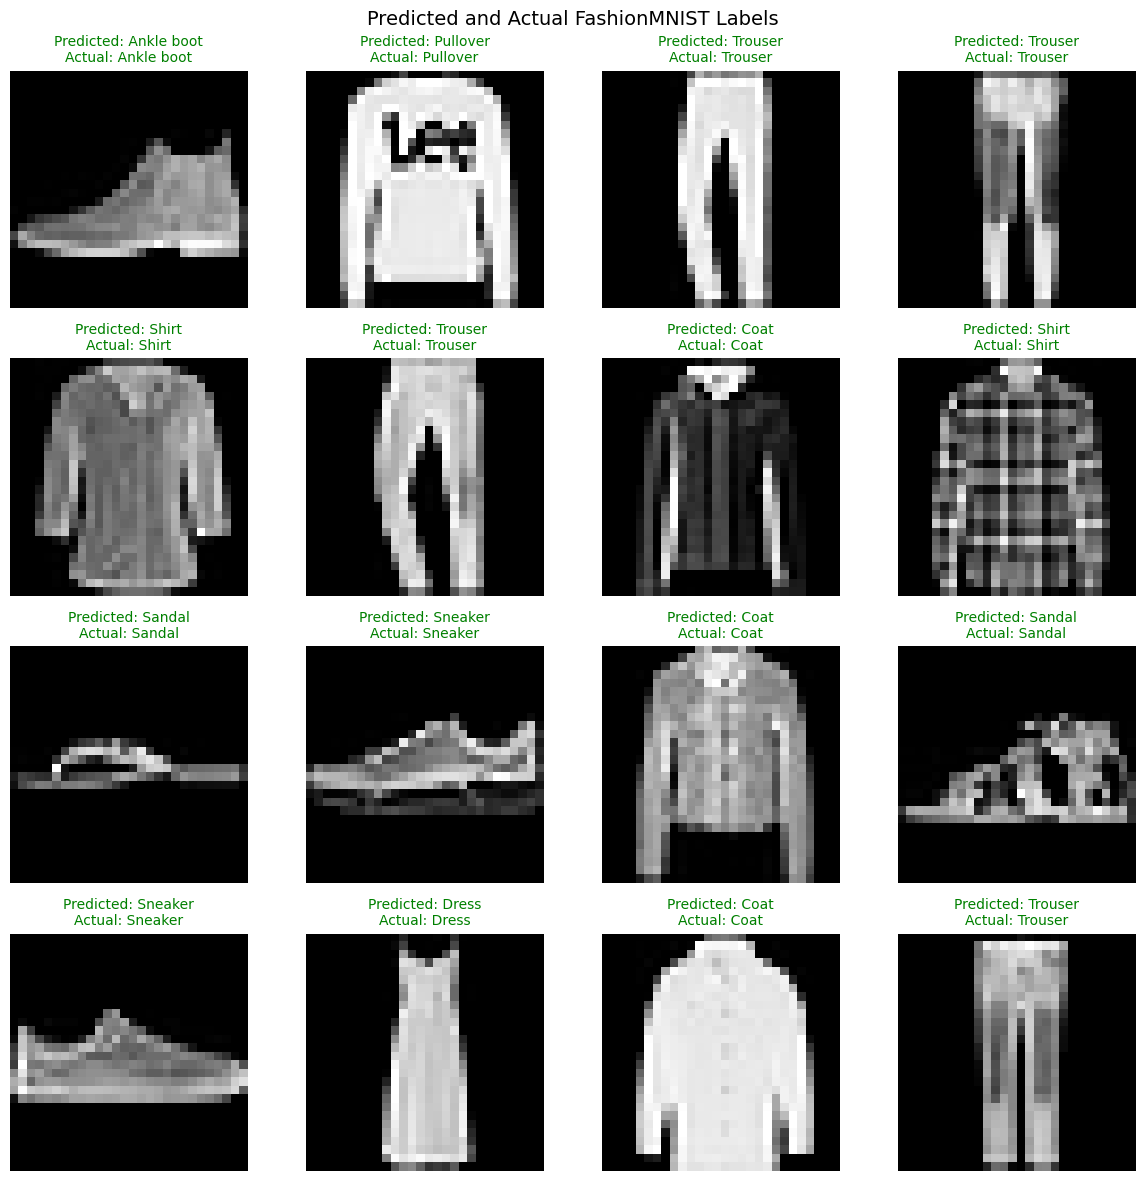

In [57]:
with torch.inference_mode():
    display_logits = loaded_model(verification_images_device)
    display_predictions = display_logits.argmax(dim=1).cpu()

display_images = (
    verification_images * TRAIN_STD + TRAIN_MEAN
).clamp(0.0, 1.0)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Predicted and Actual FashionMNIST Labels', fontsize=14)

for index, axis in enumerate(axes.flatten()):
    predicted_label = class_names[display_predictions[index].item()]
    actual_label = class_names[verification_labels[index].item()]
    title_color = (
        'green'
        if display_predictions[index] == verification_labels[index]
        else 'red'
    )
    axis.imshow(display_images[index].squeeze().numpy(), cmap='gray')
    axis.set_title(
        f'Predicted: {predicted_label}\nActual: {actual_label}',
        color=title_color,
        fontsize=10,
    )
    axis.axis('off')

plt.tight_layout()
plt.show()